In [2]:
import pandas as pd

df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
print("Kolon sayısı:", len(df_lab_raw.columns))
print("\nTüm kolonlar:")
for i, col in enumerate(df_lab_raw.columns):
    print(f"  [{i}] repr: {repr(col)}")

print("\nİlk 3 satır:")
print(df_lab_raw.head(3))

Kolon sayısı: 36

Tüm kolonlar:
  [0] repr: 'tc no (ilk 3 ve son 3 rakam)'
  [1] repr: 'cinsiyet K:1 E: 2 '
  [2] repr: 'doğum yılı'
  [3] repr: 'yaş'
  [4] repr: 'DM tanı tarihi'
  [5] repr: 'diyabet süresi (ay)'
  [6] repr: 'diyet 0:yok 1:var '
  [7] repr: 'boy (m)'
  [8] repr: 'kilo(kg)'
  [9] repr: 'BMI (kg/m2)'
  [10] repr: 'sistolik KB(mmHg)'
  [11] repr: ' diyastolik KB (mmHg)'
  [12] repr: ' nabız'
  [13] repr: 'FM’de patolojik bulgular: '
  [14] repr: 'AKŞ (mg/dL)'
  [15] repr: 'TKŞ (mg/dL)'
  [16] repr: 'A1C (%)'
  [17] repr: 'c-peptid (mcg/L)'
  [18] repr: 'üre (mg(dL)'
  [19] repr: 'kreatinin (mg/dL)'
  [20] repr: 'GFR (CKD-EPI)'
  [21] repr: 'AST (U/L)'
  [22] repr: 'ALT (U/L)'
  [23] repr: 'Ca (mg/dL)'
  [24] repr: 'P (mg/dL)'
  [25] repr: 'Cl (mmol/L)'
  [26] repr: 'alb (g/L)'
  [27] repr: 'Mg (mg/dL)'
  [28] repr: 'ALP (U/L)'
  [29] repr: 'tkol (mg/dL)'
  [30] repr: 'LDL (mg/dL)'
  [31] repr: 'HDL (mg/dL)'
  [32] repr: 'trigliserid (mg/dL)'
  [33] repr: '25OHVitD (mcg/L

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# 1) mergeAllData.xlsx
# ─────────────────────────────────────────
df_koc = pd.read_excel('mergeAllData.xlsx')

df_koc = df_koc.rename(columns={
    'Yaş'                           : 'yas',
    'Cinsiyet'                      : 'cinsiyet',
    'Açlık Kan Şekeri (AKŞ)'        : 'aks',
    'Hemoglobin (Hb A1c)'           : 'hba1c',
    'Tokluk Kan Şekeri (TKŞ) 2.Saat': 'tks',
})

for col in ['aks', 'hba1c', 'tks']:
    df_koc[col] = df_koc[col].astype(str).str.replace(',', '.', regex=False)
    df_koc[col] = pd.to_numeric(df_koc[col], errors='coerce')

df_koc['cinsiyet'] = df_koc['cinsiyet'].astype(str).str.strip().str.lower()
df_koc['cinsiyet'] = df_koc['cinsiyet'].map(lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
                                             else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_koc['bmi'] = np.nan
df_koc = df_koc[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()

# ─────────────────────────────────────────
# 2) NHANES CSV
# ─────────────────────────────────────────
df_nhanes = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')

df_nhanes = df_nhanes.rename(columns={
    'aclik_kan_sekeri_mgdl' : 'aks',
    'yas'                   : 'yas',
    'cinsiyet'              : 'cinsiyet',
    'HbA1c_pct'             : 'hba1c',
    'BMI'                   : 'bmi',
    'tokluk_2sa_mgdl'       : 'tks',
})

df_nhanes['cinsiyet'] = df_nhanes['cinsiyet'].astype(str).str.strip().str.lower()
df_nhanes['cinsiyet'] = df_nhanes['cinsiyet'].map(lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
                                                   else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nhanes = df_nhanes[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()

# ─────────────────────────────────────────
# 3) hba1cdataset.xlsx  — kolon isimleri index ile alınıyor
# ─────────────────────────────────────────
df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)

# Kolon index'e göre seç (isim boşluk/encoding sorunlarını bypass eder)
df_lab = pd.DataFrame({
    'yas'      : df_lab_raw.iloc[:, 3],   # yaş
    'cinsiyet' : df_lab_raw.iloc[:, 1],   # cinsiyet K:1 E:2
    'aks'      : df_lab_raw.iloc[:, 14],  # AKŞ (mg/dL)
    'tks'      : df_lab_raw.iloc[:, 15],  # TKŞ (mg/dL)
    'bmi'      : df_lab_raw.iloc[:, 9],   # BMI (kg/m2)
    'hba1c'    : df_lab_raw.iloc[:, 16],  # A1C (%)
})

for col in ['yas','cinsiyet','aks','tks','bmi','hba1c']:
    df_lab[col] = pd.to_numeric(df_lab[col], errors='coerce')

# cinsiyet: 1=Kadın → 1, 2=Erkek → 0
df_lab['cinsiyet'] = df_lab['cinsiyet'].map({1: 1, 2: 0})

# ─────────────────────────────────────────
# 4) Birleştir
# ─────────────────────────────────────────
df_all = pd.concat([df_koc, df_nhanes, df_lab], ignore_index=True)
df_all['kaynak'] = (['koc']*len(df_koc) + ['nhanes']*len(df_nhanes) + ['lab']*len(df_lab))

print("=== Birleşik veri seti boyutu ===")
print(df_all.shape)
print("\n=== Kaynak dağılımı ===")
print(df_all['kaynak'].value_counts())
print("\n=== Eksik değer sayıları ===")
print(df_all.isnull().sum())
print("\n=== Temel istatistikler ===")
print(df_all.describe().round(2))

=== Birleşik veri seti boyutu ===
(56357, 7)

=== Kaynak dağılımı ===
kaynak
koc       43460
nhanes    12795
lab         102
Name: count, dtype: int64

=== Eksik değer sayıları ===
yas             0
cinsiyet        0
aks          2886
tks         48389
bmi         43639
hba1c       18938
kaynak          0
dtype: int64

=== Temel istatistikler ===
       cinsiyet       aks      tks       bmi     hba1c
count  56357.00  53471.00  7968.00  12718.00  37419.00
mean       0.67    108.38   118.28     28.33      6.08
std        0.47     45.79    51.97      7.27      1.49
min        0.00     10.50    31.00     13.40      0.00
25%        0.00     86.30    88.00     23.20      5.30
50%        1.00     95.10   106.00     27.20      5.60
75%        1.00    109.80   133.00     32.00      6.30
max        1.00   1095.20   652.60     86.20     18.00


In [2]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ─────────────────────────────────────────
# 1) hba1c NaN olan satırlar → at
# ─────────────────────────────────────────
df = df_all.dropna(subset=['hba1c']).copy()
print(f"hba1c NaN atıldıktan sonra: {df.shape}")

# ─────────────────────────────────────────
# 2) Tüm sayısal kolonları zorla numeric'e çevir
#    (virgüllü string vs. kalan kalıntıları temizle)
# ─────────────────────────────────────────
for col in ['yas','aks','tks','bmi','hba1c']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ─────────────────────────────────────────
# 3) Klinik outlier sınırları
# ─────────────────────────────────────────
bounds = {
    'aks'   : (50,  600),
    'tks'   : (50,  600),
    'bmi'   : (12,   70),
    'hba1c' : (3.5,  18),
    'yas'   : (1,   110),
}
for col, (lo, hi) in bounds.items():
    before = df[col].notna().sum()
    df[col] = df[col].where((df[col] >= lo) & (df[col] <= hi))
    after  = df[col].notna().sum()
    print(f"{col}: {before - after} outlier NaN'a çevrildi")

print(f"\nTemizlik sonrası shape: {df.shape}")
print("\nEksik değer durumu:")
print(df[['yas','cinsiyet','aks','tks','bmi','hba1c']].isnull().sum())

# ─────────────────────────────────────────
# 4) MICE ile imputation (hedef hba1c hariç)
# ─────────────────────────────────────────
impute_cols = ['yas', 'cinsiyet', 'aks', 'tks', 'bmi']

imp = IterativeImputer(max_iter=10, random_state=42, min_value=0, verbose=0)
df[impute_cols] = imp.fit_transform(df[impute_cols])

# Klinikal sınırlara geri klamp
for col, (lo, hi) in bounds.items():
    if col in impute_cols:
        df[col] = df[col].clip(lo, hi)

df['cinsiyet'] = df['cinsiyet'].round().astype(int)

print("\nImputation sonrası eksik değer:")
print(df[['yas','cinsiyet','aks','tks','bmi','hba1c']].isnull().sum())
print(f"\nFinal dataset shape: {df.shape}")
print("\nTemel istatistikler:")
print(df[['yas','cinsiyet','aks','tks','bmi','hba1c']].describe().round(2))

hba1c NaN atıldıktan sonra: (37419, 7)
aks: 37 outlier NaN'a çevrildi
tks: 59 outlier NaN'a çevrildi
bmi: 4 outlier NaN'a çevrildi
hba1c: 7 outlier NaN'a çevrildi
yas: 0 outlier NaN'a çevrildi

Temizlik sonrası shape: (37419, 7)

Eksik değer durumu:
yas         25195
cinsiyet        0
aks          1752
tks         29635
bmi         25350
hba1c           7
dtype: int64

Imputation sonrası eksik değer:
yas         0
cinsiyet    0
aks         0
tks         0
bmi         0
hba1c       7
dtype: int64

Final dataset shape: (37419, 7)

Temel istatistikler:
            yas  cinsiyet       aks       tks       bmi     hba1c
count  37419.00  37419.00  37419.00  37419.00  37419.00  37412.00
mean      44.69      0.64    111.38    138.00     28.70      6.08
std       13.62      0.48     45.51     78.40      4.50      1.49
min       12.00      0.00     50.00     50.00     13.40      3.50
25%       40.07      0.00     88.70     95.23     27.25      5.30
50%       42.52      1.00     98.00    113.99   

Model verisi: (37412, 7)
Train: (31800, 15)  |  Test: (5612, 15)

─────────────────────────────────────────────
  Ridge [TEST]
─────────────────────────────────────────────
  R²    : 0.6190
  MAE   : 0.5656
  MSE   : 0.8649
  RMSE  : 0.9300
  MAPE  : 8.74%
  CV R²: 0.6105 ± 0.0135  |  süre: 3.4s

─────────────────────────────────────────────
  Lasso [TEST]
─────────────────────────────────────────────
  R²    : 0.6122
  MAE   : 0.5710
  MSE   : 0.8805
  RMSE  : 0.9384
  MAPE  : 8.82%
  CV R²: 0.6003 ± 0.0138  |  süre: 2.9s

─────────────────────────────────────────────
  RandomForest [TEST]
─────────────────────────────────────────────
  R²    : 0.5763
  MAE   : 0.5997
  MSE   : 0.9619
  RMSE  : 0.9808
  MAPE  : 9.18%
  CV R²: 0.5574 ± 0.0138  |  süre: 38.1s

─────────────────────────────────────────────
  GradientBoosting [TEST]
─────────────────────────────────────────────
  R²    : 0.6344
  MAE   : 0.5524
  MSE   : 0.8301
  RMSE  : 0.9111
  MAPE  : 8.52%
  CV R²: 0.6216 ± 0.0132  | 

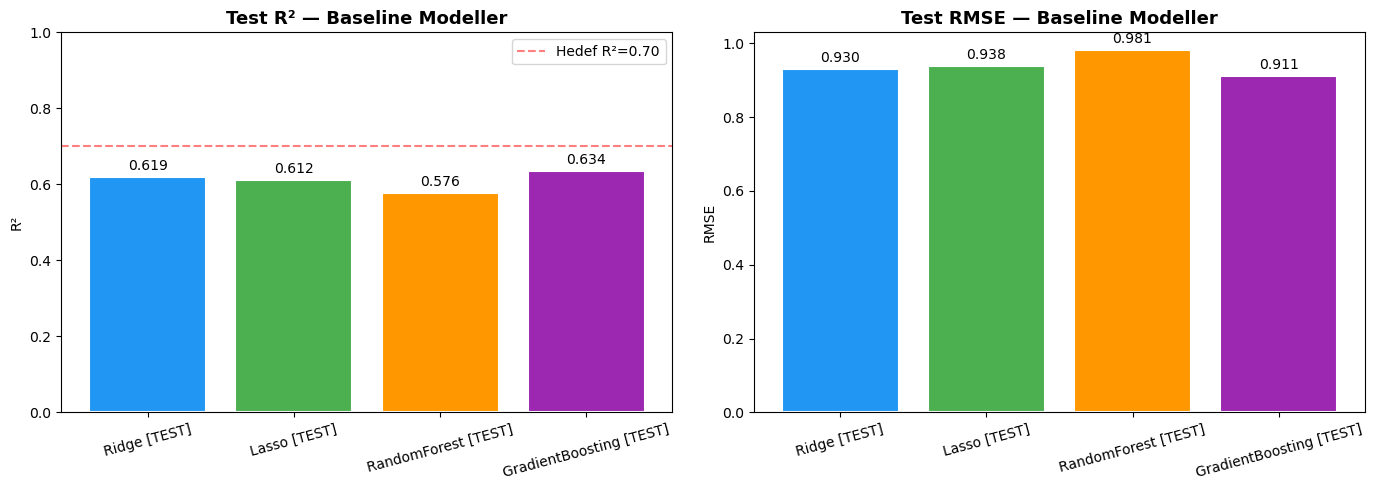


Grafik kaydedildi: baseline_karsilastirma.png


In [3]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import joblib, time

# ─────────────────────────────────────────
# 1) hba1c NaN olan 7 satırı at (hedef eksik)
# ─────────────────────────────────────────
df_model = df.dropna(subset=['hba1c']).copy()
print(f"Model verisi: {df_model.shape}")

# ─────────────────────────────────────────
# 2) Feature Engineering
# ─────────────────────────────────────────
# Klinik olarak anlamlı etkileşimler
df_model['aks_tks_oran']   = df_model['tks'] / (df_model['aks'] + 1e-6)
df_model['aks_tks_fark']   = df_model['tks'] - df_model['aks']
df_model['bmi_yas']        = df_model['bmi'] * df_model['yas']
df_model['aks_kare']       = df_model['aks'] ** 2
df_model['tks_kare']       = df_model['tks'] ** 2
df_model['yas_kare']       = df_model['yas'] ** 2
df_model['obezite']        = (df_model['bmi'] >= 30).astype(int)
df_model['yasli']          = (df_model['yas'] >= 65).astype(int)
df_model['yuksek_aks']     = (df_model['aks'] >= 126).astype(int)   # DM eşiği
df_model['yuksek_tks']     = (df_model['tks'] >= 200).astype(int)   # DM eşiği

FEATURES = [
    'yas','cinsiyet','aks','tks','bmi',
    'aks_tks_oran','aks_tks_fark','bmi_yas',
    'aks_kare','tks_kare','yas_kare',
    'obezite','yasli','yuksek_aks','yuksek_tks'
]

X = df_model[FEATURES].values
y = df_model['hba1c'].values

# ─────────────────────────────────────────
# 3) Train/Test Split — ÖNCE split, SONRA scale
#    (veri sızıntısı yok)
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit sadece train'de
X_test_sc  = scaler.transform(X_test)        # test sadece transform

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

# ─────────────────────────────────────────
# 4) Metrik fonksiyonu
# ─────────────────────────────────────────
def metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  R²    : {r2:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MSE   : {mse:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAPE  : {mape:.2f}%")
    return {'model':name,'R2':r2,'MAE':mae,'MSE':mse,'RMSE':rmse,'MAPE':mape}

# ─────────────────────────────────────────
# 5) Baseline modeller + 5-Fold CV
# ─────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

baseline_models = {
    'Ridge'           : Ridge(alpha=1.0),
    'Lasso'           : Lasso(alpha=0.01),
    'RandomForest'    : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

for name, model in baseline_models.items():
    t0 = time.time()
    # 5-Fold CV (train seti üzerinde)
    cv = cross_validate(model, X_train_sc, y_train, cv=kf,
                        scoring=['r2','neg_mean_absolute_error','neg_root_mean_squared_error'],
                        return_train_score=False, n_jobs=-1)
    # Test seti tahmini
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    r = metrics(f"{name} [TEST]", y_test, y_pred)
    r['CV_R2_mean']  = cv['test_r2'].mean()
    r['CV_R2_std']   = cv['test_r2'].std()
    r['CV_MAE_mean'] = (-cv['test_neg_mean_absolute_error']).mean()
    r['CV_RMSE_mean']= (-cv['test_neg_root_mean_squared_error']).mean()
    r['sure_sn']     = round(time.time()-t0, 1)
    results.append(r)
    print(f"  CV R²: {r['CV_R2_mean']:.4f} ± {r['CV_R2_std']:.4f}  |  süre: {r['sure_sn']}s")

# ─────────────────────────────────────────
# 6) Karşılaştırma tablosu
# ─────────────────────────────────────────
df_res = pd.DataFrame(results).set_index('model')
print("\n\n=== BASELINE KARŞILAŞTIRMA TABLOSU ===")
print(df_res[['R2','MAE','RMSE','MAPE','CV_R2_mean','CV_R2_std']].round(4).to_string())

# ─────────────────────────────────────────
# 7) Görselleştirme
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — R²
ax = axes[0]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
bars = ax.bar(df_res.index, df_res['R2'], color=colors, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('Test R² — Baseline Modeller', fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, 1)
ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Hedef R²=0.70')
ax.legend()
ax.tick_params(axis='x', rotation=15)

# Bar chart — RMSE
ax = axes[1]
bars2 = ax.bar(df_res.index, df_res['RMSE'], color=colors, edgecolor='white', linewidth=1.5)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('Test RMSE — Baseline Modeller', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('baseline_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGrafik kaydedildi: baseline_karsilastirma.png")

In [8]:
import subprocess, sys

packages = ['lightgbm', 'catboost', 'optuna']
for pkg in packages:
    print(f"{pkg} kuruluyor...")
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  ✅ {pkg} kuruldu")
    else:
        print(f"  ❌ {pkg} HATA: {result.stderr[-200:]}")

lightgbm kuruluyor...
  ✅ lightgbm kuruldu
catboost kuruluyor...
  ✅ catboost kuruldu
optuna kuruluyor...
  ✅ optuna kuruldu


XGBoost Optuna optimizasyonu başlıyor (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]


════════════════════════════════════════════════
  XGBoost [Optuna]
════════════════════════════════════════════════
  R²    : 0.6391
  MAE   : 0.5491
  MSE   : 0.8195
  RMSE  : 0.9053
  MAPE  : 8.48%
  CV R² : 0.6282 ± 0.0114
  Best params: {'n_estimators': 917, 'max_depth': 7, 'learning_rate': 0.006047360568422396, 'subsample': 0.8037724259507192, 'colsample_bytree': 0.502314474212375, 'min_child_weight': 1, 'reg_alpha': 5.5517216852447255, 'reg_lambda': 6.732248920775331, 'gamma': 4.041986740582305}

LightGBM Optuna optimizasyonu başlıyor (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]


════════════════════════════════════════════════
  LightGBM [Optuna]
════════════════════════════════════════════════
  R²    : 0.6379
  MAE   : 0.5496
  MSE   : 0.8222
  RMSE  : 0.9068
  MAPE  : 8.49%
  CV R² : 0.6279 ± 0.0114
  Best params: {'n_estimators': 613, 'max_depth': 5, 'learning_rate': 0.008322344862344141, 'num_leaves': 160, 'subsample': 0.7558306618263463, 'colsample_bytree': 0.4701349724446858, 'min_child_samples': 90, 'reg_alpha': 2.486779059253887, 'reg_lambda': 0.0001627144005896931}

CatBoost Optuna optimizasyonu başlıyor (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]


════════════════════════════════════════════════
  CatBoost [Optuna]
════════════════════════════════════════════════
  R²    : 0.6383
  MAE   : 0.5491
  MSE   : 0.8212
  RMSE  : 0.9062
  MAPE  : 8.47%
  CV R² : 0.6288 ± 0.0120
  Best params: {'iterations': 1362, 'depth': 8, 'learning_rate': 0.008495053360772102, 'l2_leaf_reg': 0.7216475055894009, 'bagging_temperature': 0.36841491183500674, 'random_strength': 3.0196269585235043, 'border_count': 229}


=== BOOST MODEL KARŞILAŞTIRMA ===
                       R2     MAE    RMSE    MAPE   CV_R2  CV_std
model                                                            
XGBoost [Optuna]   0.6391  0.5491  0.9053  8.4848  0.6282  0.0114
LightGBM [Optuna]  0.6379  0.5496  0.9068  8.4922  0.6279  0.0114
CatBoost [Optuna]  0.6383  0.5491  0.9062  8.4745  0.6288  0.0120


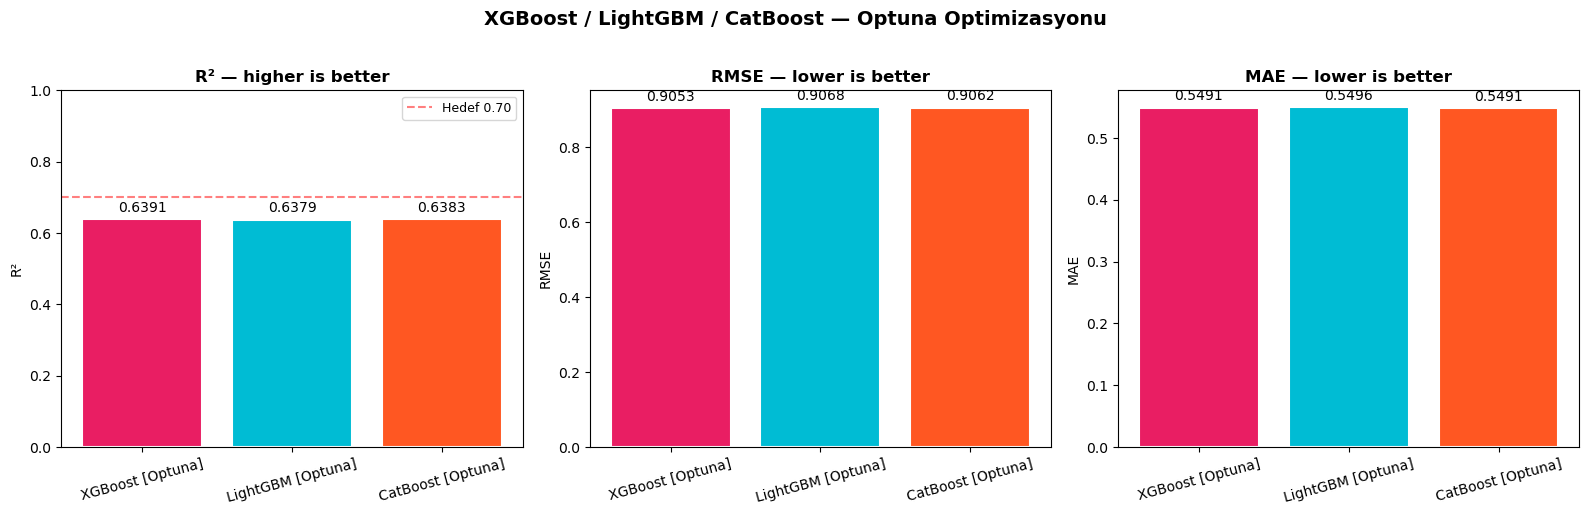

Grafik kaydedildi: boost_karsilastirma.png


In [4]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# Ortak yardımcı
# ─────────────────────────────────────────
def eval_metrics(name, y_true, y_pred, cv_r2=None, cv_std=None):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    print(f"\n{'═'*48}")
    print(f"  {name}")
    print(f"{'═'*48}")
    print(f"  R²    : {r2:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MSE   : {mse:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAPE  : {mape:.2f}%")
    if cv_r2: print(f"  CV R² : {cv_r2:.4f} ± {cv_std:.4f}")
    return {'model':name,'R2':r2,'MAE':mae,'MSE':mse,'RMSE':rmse,'MAPE':mape,
            'CV_R2':cv_r2 or 0,'CV_std':cv_std or 0}

boost_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════
# 1) XGBoost — Optuna (50 trial)
# ═══════════════════════════════════════════
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1500),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        gamma             = trial.suggest_float('gamma', 0, 5),
        random_state=42, tree_method='hist', n_jobs=-1
    )
    model = xgb.XGBRegressor(**params)
    scores = cross_validate(model, X_train_sc, y_train, cv=kf,
                            scoring='r2', n_jobs=-1)
    return scores['test_score'].mean()

print("XGBoost Optuna optimizasyonu başlıyor (50 trial)...")
xgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_xgb = xgb.XGBRegressor(**xgb_study.best_params,
                              random_state=42, tree_method='hist', n_jobs=-1)
cv_xgb = cross_validate(best_xgb, X_train_sc, y_train, cv=kf, scoring='r2', n_jobs=-1)
best_xgb.fit(X_train_sc, y_train)
y_pred_xgb = best_xgb.predict(X_test_sc)
r = eval_metrics("XGBoost [Optuna]", y_test, y_pred_xgb,
                 cv_xgb['test_score'].mean(), cv_xgb['test_score'].std())
boost_results.append(r)
print(f"  Best params: {xgb_study.best_params}")

# ═══════════════════════════════════════════
# 2) LightGBM — Optuna (50 trial)
# ═══════════════════════════════════════════
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1500),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 200),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        random_state=42, n_jobs=-1, verbose=-1
    )
    model = lgb.LGBMRegressor(**params)
    scores = cross_validate(model, X_train_sc, y_train, cv=kf,
                            scoring='r2', n_jobs=-1)
    return scores['test_score'].mean()

print("\nLightGBM Optuna optimizasyonu başlıyor (50 trial)...")
lgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

best_lgb = lgb.LGBMRegressor(**lgb_study.best_params,
                               random_state=42, n_jobs=-1, verbose=-1)
cv_lgb = cross_validate(best_lgb, X_train_sc, y_train, cv=kf, scoring='r2', n_jobs=-1)
best_lgb.fit(X_train_sc, y_train)
y_pred_lgb = best_lgb.predict(X_test_sc)
r = eval_metrics("LightGBM [Optuna]", y_test, y_pred_lgb,
                 cv_lgb['test_score'].mean(), cv_lgb['test_score'].std())
boost_results.append(r)
print(f"  Best params: {lgb_study.best_params}")

# ═══════════════════════════════════════════
# 3) CatBoost — Optuna (50 trial)
# ═══════════════════════════════════════════
def cat_objective(trial):
    params = dict(
        iterations        = trial.suggest_int('iterations', 300, 1500),
        depth             = trial.suggest_int('depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0, 1),
        random_strength   = trial.suggest_float('random_strength', 1e-3, 10, log=True),
        border_count      = trial.suggest_int('border_count', 32, 255),
        random_seed=42, verbose=False
    )
    model = CatBoostRegressor(**params)
    scores = cross_validate(model, X_train_sc, y_train, cv=kf,
                            scoring='r2', n_jobs=1)
    return scores['test_score'].mean()

print("\nCatBoost Optuna optimizasyonu başlıyor (50 trial)...")
cat_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=True)

best_cat = CatBoostRegressor(**cat_study.best_params, random_seed=42, verbose=False)
cv_cat = cross_validate(best_cat, X_train_sc, y_train, cv=kf, scoring='r2', n_jobs=1)
best_cat.fit(X_train_sc, y_train)
y_pred_cat = best_cat.predict(X_test_sc)
r = eval_metrics("CatBoost [Optuna]", y_test, y_pred_cat,
                 cv_cat['test_score'].mean(), cv_cat['test_score'].std())
boost_results.append(r)
print(f"  Best params: {cat_study.best_params}")

# ═══════════════════════════════════════════
# 4) Karşılaştırma + Grafik
# ═══════════════════════════════════════════
df_boost = pd.DataFrame(boost_results).set_index('model')
print("\n\n=== BOOST MODEL KARŞILAŞTIRMA ===")
print(df_boost[['R2','MAE','RMSE','MAPE','CV_R2','CV_std']].round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#E91E63','#00BCD4','#FF5722']
metrics_plot = [('R2','R²','higher is better'),
                ('RMSE','RMSE','lower is better'),
                ('MAE','MAE','lower is better')]

for ax, (m, label, note) in zip(axes, metrics_plot):
    bars = ax.bar(df_boost.index, df_boost[m], color=colors, edgecolor='white', lw=1.5)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
    ax.set_title(f'{label} — {note}', fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)
    if m == 'R2':
        ax.set_ylim(0, 1)
        ax.axhline(0.7, color='red', ls='--', alpha=0.5, label='Hedef 0.70')
        ax.legend(fontsize=9)

plt.suptitle('XGBoost / LightGBM / CatBoost — Optuna Optimizasyonu', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boost_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: boost_karsilastirma.png")

In [5]:
# ─────────────────────────────────────────
# Orijinal df_all'dan gerçek tks olan satırları işaretle
# ─────────────────────────────────────────

# df_all'ı tekrar yükle (imputation öncesi)
df_koc2 = pd.read_excel('mergeAllData.xlsx')
df_koc2 = df_koc2.rename(columns={
    'Yaş':'yas','Cinsiyet':'cinsiyet',
    'Açlık Kan Şekeri (AKŞ)':'aks',
    'Hemoglobin (Hb A1c)':'hba1c',
    'Tokluk Kan Şekeri (TKŞ) 2.Saat':'tks'
})
for col in ['aks','hba1c','tks']:
    df_koc2[col] = df_koc2[col].astype(str).str.replace(',','.').pipe(pd.to_numeric, errors='coerce')
df_koc2['bmi'] = np.nan
df_koc2['cinsiyet'] = df_koc2['cinsiyet'].astype(str).str.strip().str.lower()
df_koc2['cinsiyet'] = df_koc2['cinsiyet'].map(lambda x: 1 if x in ['k','kadin','kadın'] else (0 if x in ['e','erkek'] else np.nan))
df_koc2 = df_koc2[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()

df_nhanes2 = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv').rename(columns={
    'aclik_kan_sekeri_mgdl':'aks','yas':'yas','cinsiyet':'cinsiyet',
    'HbA1c_pct':'hba1c','BMI':'bmi','tokluk_2sa_mgdl':'tks'
})
df_nhanes2['cinsiyet'] = df_nhanes2['cinsiyet'].astype(str).str.lower().map(
    lambda x: 1 if x in ['k','kadin','kadın'] else (0 if x in ['e','erkek'] else np.nan))
df_nhanes2 = df_nhanes2[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()

df_lab2 = pd.read_excel('hba1cdataset.xlsx', header=1)
df_lab2 = pd.DataFrame({
    'yas':df_lab2.iloc[:,3],'cinsiyet':df_lab2.iloc[:,1],
    'aks':df_lab2.iloc[:,14],'tks':df_lab2.iloc[:,15],
    'bmi':df_lab2.iloc[:,9],'hba1c':df_lab2.iloc[:,16]
})
for col in df_lab2.columns:
    df_lab2[col] = pd.to_numeric(df_lab2[col], errors='coerce')
df_lab2['cinsiyet'] = df_lab2['cinsiyet'].map({1:1, 2:0})

df_raw = pd.concat([df_koc2, df_nhanes2, df_lab2], ignore_index=True)
df_raw['kaynak'] = ['koc']*len(df_koc2) + ['nhanes']*len(df_nhanes2) + ['lab']*len(df_lab2)

# Outlier temizliği
bounds = {'aks':(50,600),'tks':(50,600),'bmi':(12,70),'hba1c':(3.5,18),'yas':(1,110)}
for col,(lo,hi) in bounds.items():
    df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(',','.'), errors='coerce')
    df_raw[col] = df_raw[col].where((df_raw[col]>=lo)&(df_raw[col]<=hi))

df_raw = df_raw.dropna(subset=['hba1c'])

# ─────────────────────────────────────────
# Gerçek tks olan vs olmayan karşılaştır
# ─────────────────────────────────────────
has_tks    = df_raw[df_raw['tks'].notna()]
no_tks     = df_raw[df_raw['tks'].isna()]
has_bmi    = df_raw[df_raw['bmi'].notna()]

print("=== VERİ KALİTESİ ANALİZİ ===")
print(f"\nToplam (hba1c olan): {len(df_raw)}")
print(f"Gerçek TKS olan    : {len(has_tks)} ({100*len(has_tks)/len(df_raw):.1f}%)")
print(f"Gerçek TKS YOK     : {len(no_tks)} ({100*len(no_tks)/len(df_raw):.1f}%)")
print(f"Gerçek BMI olan    : {len(has_bmi)} ({100*len(has_bmi)/len(df_raw):.1f}%)")

print(f"\n--- Gerçek TKS olan grupta HbA1c istatistikleri ---")
print(has_tks['hba1c'].describe().round(3))

print(f"\n--- Gerçek TKS YOK grupta HbA1c istatistikleri ---")
print(no_tks['hba1c'].describe().round(3))

# ─────────────────────────────────────────
# Sadece GERÇEK değerleri olan subset ile model dene
# ─────────────────────────────────────────
print("\n\n=== SADECE GERÇEK TKS OLAN SATIRLARLA MODEL ===")
df_real = has_tks.copy()

# BMI eksikse sadece aks/tks/yas/cinsiyet ile doldur
for col in ['aks','bmi','cinsiyet','yas']:
    df_real[col] = pd.to_numeric(df_real[col], errors='coerce')
df_real = df_real.dropna(subset=['aks','tks','yas','cinsiyet','hba1c'])

# Feature engineering
df_real['aks_tks_oran'] = df_real['tks'] / (df_real['aks'] + 1e-6)
df_real['aks_tks_fark'] = df_real['tks'] - df_real['aks']
df_real['yuksek_aks']   = (df_real['aks'] >= 126).astype(int)
df_real['yuksek_tks']   = (df_real['tks'] >= 200).astype(int)

# BMI varsa kullan, yoksa at (önce dene)
FEAT_NO_BMI = ['yas','cinsiyet','aks','tks','aks_tks_oran','aks_tks_fark','yuksek_aks','yuksek_tks']
FEAT_BMI    = FEAT_NO_BMI + ['bmi']

for feat_set, label in [(FEAT_NO_BMI,'BMIsiz'), (FEAT_BMI,'BMIli')]:
    subset = df_real.dropna(subset=feat_set+['hba1c'])
    if len(subset) < 100:
        print(f"{label}: yeterli veri yok ({len(subset)})")
        continue

    X_ = subset[feat_set].values
    y_ = subset['hba1c'].values
    Xtr, Xte, ytr, yte = train_test_split(X_, y_, test_size=0.15, random_state=42)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)

    m = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, tree_method='hist', n_jobs=-1)
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    r2   = r2_score(yte, yp)
    mae  = mean_absolute_error(yte, yp)
    rmse = np.sqrt(mean_squared_error(yte, yp))
    print(f"\n[XGB - Gerçek Veri - {label}]  n={len(subset)}")
    print(f"  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

print("\nKaynak bazında gerçek TKS dağılımı:")
print(df_raw.groupby('kaynak')['tks'].agg(['count','notna']).assign(
    gercek_tks=lambda x: x['notna']).drop('notna',axis=1))
print(df_raw.groupby('kaynak')[['tks','bmi','hba1c']].apply(lambda g: g.notna().sum()))

=== VERİ KALİTESİ ANALİZİ ===

Toplam (hba1c olan): 37412
Gerçek TKS olan    : 7784 (20.8%)
Gerçek TKS YOK     : 29628 (79.2%)
Gerçek BMI olan    : 12069 (32.3%)

--- Gerçek TKS olan grupta HbA1c istatistikleri ---
count    7784.000
mean        5.520
std         0.712
min         3.600
25%         5.200
50%         5.400
75%         5.700
max        14.000
Name: hba1c, dtype: float64

--- Gerçek TKS YOK grupta HbA1c istatistikleri ---
count    29628.000
mean         6.227
std          1.603
min          3.500
25%          5.300
50%          5.700
75%          6.500
max         18.000
Name: hba1c, dtype: float64


=== SADECE GERÇEK TKS OLAN SATIRLARLA MODEL ===

[XGB - Gerçek Veri - BMIsiz]  n=6747
  R²=0.6698  MAE=0.3006  RMSE=0.4076

[XGB - Gerçek Veri - BMIli]  n=6706
  R²=0.6609  MAE=0.3057  RMSE=0.4174

Kaynak bazında gerçek TKS dağılımı:


AttributeError: 'SeriesGroupBy' object has no attribute 'notna'

Çalışma verisi: (12151, 7)
TKS tahmin modeli R²: 0.5412
Train: (10328, 16)  Test: (1823, 16)

Stacking modeli eğitiliyor...

════════════════════════════════════════════════
  STACKING [TEST]
════════════════════════════════════════════════
  R²    : 0.7046
  MAE   : 0.3650
  MSE   : 0.3800
  RMSE  : 0.6164
  MAPE  : 5.98%


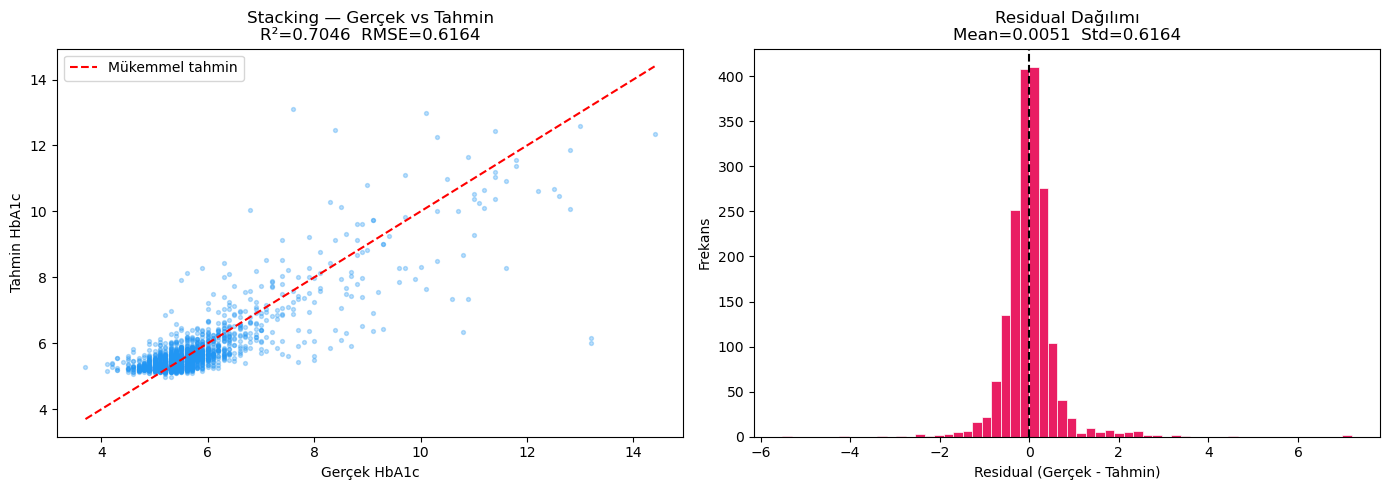

Grafik kaydedildi: stacking_sonuc.png


In [6]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ─────────────────────────────────────────
# Strateji: TKS'yi ayrı bir modelle tahmin et,
# sonra tahmin edilen TKS'yi feature olarak kullan
# (sadece train üzerinde fit → sızıntı yok)
# ─────────────────────────────────────────

# Tekrar temiz df_raw kullan (imputation öncesi)
df_work = df_raw.copy()

# Tüm sayısalları zorla numeric
for col in ['yas','cinsiyet','aks','tks','bmi','hba1c']:
    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

df_work['cinsiyet'] = df_work['cinsiyet'].round()

# hba1c NaN olan → at
df_work = df_work.dropna(subset=['hba1c','aks','yas','cinsiyet'])
print(f"Çalışma verisi: {df_work.shape}")

# ─────────────────────────────────────────
# Feature engineering (TKS henüz NaN olabilir)
# ─────────────────────────────────────────
df_work['yuksek_aks']  = (df_work['aks'] >= 126).astype(int)
df_work['obezite']     = (df_work['bmi'] >= 30).astype(float)  # NaN kalabilir
df_work['yas_kare']    = df_work['yas'] ** 2
df_work['aks_kare']    = df_work['aks'] ** 2

# ─────────────────────────────────────────
# ADIM 1: TKS Tahmin Modeli
# (sadece gerçek TKS olan satırlarla eğit)
# ─────────────────────────────────────────
TKS_FEAT = ['yas','cinsiyet','aks','aks_kare','yuksek_aks']
df_tks_train = df_work[df_work['tks'].notna()].dropna(subset=TKS_FEAT)

X_tks = df_tks_train[TKS_FEAT].values
y_tks = df_tks_train['tks'].values

Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(X_tks, y_tks, test_size=0.2, random_state=42)
sc_tks = StandardScaler()
Xtr_t_sc = sc_tks.fit_transform(Xtr_t)
Xte_t_sc  = sc_tks.transform(Xte_t)

tks_model = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, tree_method='hist', n_jobs=-1)
tks_model.fit(Xtr_t_sc, ytr_t)
tks_r2 = r2_score(yte_t, tks_model.predict(Xte_t_sc))
print(f"TKS tahmin modeli R²: {tks_r2:.4f}")

# ─────────────────────────────────────────
# ADIM 2: Ana veri setinde TKS doldur
# (gerçek TKS varsa onu kullan, yoksa tahmin et)
# ─────────────────────────────────────────
missing_tks_mask = df_work['tks'].isna()
X_fill = sc_tks.transform(df_work.loc[missing_tks_mask, TKS_FEAT].fillna(df_work[TKS_FEAT].median()))
df_work.loc[missing_tks_mask, 'tks'] = tks_model.predict(X_fill).clip(50, 600)
df_work.loc[missing_tks_mask, 'tks_imputed'] = 1
df_work.loc[~missing_tks_mask, 'tks_imputed'] = 0

# BMI: median impute (basit, az etkili)
bmi_median = df_work['bmi'].median()
df_work['bmi'] = df_work['bmi'].fillna(bmi_median)
df_work['obezite'] = (df_work['bmi'] >= 30).astype(int)

# ─────────────────────────────────────────
# ADIM 3: Final feature seti
# ─────────────────────────────────────────
df_work['aks_tks_oran'] = df_work['tks'] / (df_work['aks'] + 1e-6)
df_work['aks_tks_fark'] = df_work['tks'] - df_work['aks']
df_work['tks_kare']     = df_work['tks'] ** 2
df_work['yuksek_tks']   = (df_work['tks'] >= 200).astype(int)
df_work['bmi_yas']      = df_work['bmi'] * df_work['yas']
df_work['yasli']        = (df_work['yas'] >= 65).astype(int)

FINAL_FEAT = [
    'yas','cinsiyet','aks','tks','bmi',
    'aks_tks_oran','aks_tks_fark',
    'aks_kare','tks_kare','yas_kare',
    'obezite','yasli','yuksek_aks','yuksek_tks',
    'bmi_yas','tks_imputed'
]

X_final = df_work[FINAL_FEAT].values
y_final = df_work['hba1c'].values

# ─────────────────────────────────────────
# ADIM 4: Train/Test split → scale
# ─────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.15, random_state=42)
sc_final = StandardScaler()
X_tr_sc = sc_final.fit_transform(X_tr)
X_te_sc  = sc_final.transform(X_te)
print(f"Train: {X_tr_sc.shape}  Test: {X_te_sc.shape}")

# ─────────────────────────────────────────
# ADIM 5: Stacking (XGB + LGB + CAT → Ridge meta)
# ─────────────────────────────────────────
estimators = [
    ('xgb', xgb.XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.03,
                               subsample=0.8, colsample_bytree=0.8,
                               reg_alpha=0.1, reg_lambda=1.0,
                               random_state=42, tree_method='hist', n_jobs=-1)),
    ('lgb', lgb.LGBMRegressor(n_estimators=800, max_depth=6, learning_rate=0.03,
                                num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                random_state=42, n_jobs=-1, verbose=-1)),
    ('cat', CatBoostRegressor(iterations=800, depth=6, learning_rate=0.03,
                               l2_leaf_reg=1.0, random_seed=42, verbose=False)),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0]),
    cv=5, n_jobs=1
)

print("\nStacking modeli eğitiliyor...")
stack.fit(X_tr_sc, y_tr)
y_pred_stack = stack.predict(X_te_sc)

r2   = r2_score(y_te, y_pred_stack)
mae  = mean_absolute_error(y_te, y_pred_stack)
mse  = mean_squared_error(y_te, y_pred_stack)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_te - y_pred_stack)/(y_te+1e-6)))*100

print(f"\n{'═'*48}")
print(f"  STACKING [TEST]")
print(f"{'═'*48}")
print(f"  R²    : {r2:.4f}")
print(f"  MAE   : {mae:.4f}")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  MAPE  : {mape:.2f}%")

# Gerçek vs tahmin scatter
fig, axes = plt.subplots(1, 2, figsize=(14,5))

ax = axes[0]
ax.scatter(y_te, y_pred_stack, alpha=0.3, s=8, color='#2196F3')
lims = [min(y_te.min(), y_pred_stack.min()), max(y_te.max(), y_pred_stack.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Mükemmel tahmin')
ax.set_xlabel('Gerçek HbA1c')
ax.set_ylabel('Tahmin HbA1c')
ax.set_title(f'Stacking — Gerçek vs Tahmin\nR²={r2:.4f}  RMSE={rmse:.4f}')
ax.legend()

# Residual dağılımı
residuals = y_te - y_pred_stack
ax = axes[1]
ax.hist(residuals, bins=60, color='#E91E63', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Residual (Gerçek - Tahmin)')
ax.set_ylabel('Frekans')
ax.set_title(f'Residual Dağılımı\nMean={residuals.mean():.4f}  Std={residuals.std():.4f}')

plt.tight_layout()
plt.savefig('stacking_sonuc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: stacking_sonuc.png")

XGBoost optimize ediliyor (40 trial)...


  0%|          | 0/40 [00:00<?, ?it/s]

  XGB opt → R²=0.7128  RMSE=0.6078

LightGBM optimize ediliyor (40 trial)...


  0%|          | 0/40 [00:00<?, ?it/s]

  LGB opt → R²=0.7078  RMSE=0.6131

CatBoost optimize ediliyor (40 trial)...


  0%|          | 0/40 [00:00<?, ?it/s]

  CAT opt → R²=0.7120  RMSE=0.6087

MLP optimize ediliyor (40 trial)...


  0%|          | 0/40 [00:00<?, ?it/s]

  MLP opt → R²=0.7121  RMSE=0.6085

Optimized Stacking eğitiliyor...

══════════════════════════════════════════════════
  OPTİMİZE STACKING [TEST]
══════════════════════════════════════════════════
  R²    : 0.7156
  MAE   : 0.3611
  RMSE  : 0.6049
  MAPE  : 5.90%

=== TÜM MODELLER KARŞILAŞTIRMA ===
               R2     MAE    RMSE    MAPE
model                                    
XGB_opt    0.7128  0.3629  0.6078  5.9503
LGB_opt    0.7078  0.3662  0.6131  5.9932
CAT_opt    0.7120  0.3621  0.6087  5.9358
MLP_opt    0.7121  0.3664  0.6085  5.9945
STACK_opt  0.7156  0.3611  0.6049  5.9047


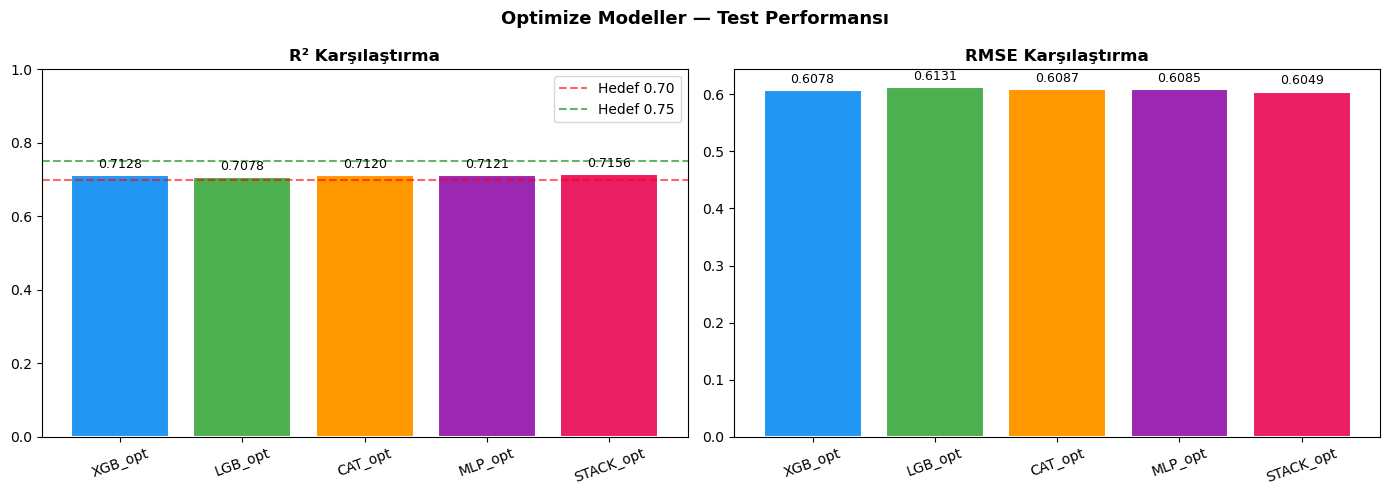

Grafik kaydedildi: optimize_karsilastirma.png


In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV, ElasticNetCV
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

all_results = []

# ─────────────────────────────────────────
# 1) XGBoost Optuna (40 trial)
# ─────────────────────────────────────────
def xgb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 500, 2000),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('lr', 0.005, 0.1, log=True),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample', 0.5, 1.0),
        min_child_weight = trial.suggest_int('mcw', 1, 10),
        reg_alpha        = trial.suggest_float('alpha', 1e-4, 5, log=True),
        reg_lambda       = trial.suggest_float('lambda', 1e-4, 5, log=True),
        gamma            = trial.suggest_float('gamma', 0, 3),
    )
    m = xgb.XGBRegressor(**p, random_state=42, tree_method='hist', n_jobs=-1)
    cv = cross_validate(m, X_tr_sc, y_tr, cv=KFold(5,shuffle=True,random_state=42),
                        scoring='r2', n_jobs=-1)
    return cv['test_score'].mean()

print("XGBoost optimize ediliyor (40 trial)...")
s1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
s1.optimize(xgb_obj, n_trials=40, show_progress_bar=True)
best_xgb = xgb.XGBRegressor(**{k.replace('lr','learning_rate').replace('colsample','colsample_bytree')
                                 .replace('mcw','min_child_weight').replace('alpha','reg_alpha')
                                 .replace('lambda','reg_lambda'): v
                                 for k,v in s1.best_params.items()},
                              random_state=42, tree_method='hist', n_jobs=-1)
# düzgün param mapping
bp = s1.best_params
best_xgb = xgb.XGBRegressor(
    n_estimators=bp['n_estimators'], max_depth=bp['max_depth'],
    learning_rate=bp['lr'], subsample=bp['subsample'],
    colsample_bytree=bp['colsample'], min_child_weight=bp['mcw'],
    reg_alpha=bp['alpha'], reg_lambda=bp['lambda'], gamma=bp['gamma'],
    random_state=42, tree_method='hist', n_jobs=-1
)
best_xgb.fit(X_tr_sc, y_tr)
yp = best_xgb.predict(X_te_sc)
r = {'model':'XGB_opt','R2':r2_score(y_te,yp),'MAE':mean_absolute_error(y_te,yp),
     'RMSE':np.sqrt(mean_squared_error(y_te,yp)),
     'MAPE':np.mean(np.abs((y_te-yp)/(y_te+1e-6)))*100}
all_results.append(r)
print(f"  XGB opt → R²={r['R2']:.4f}  RMSE={r['RMSE']:.4f}")

# ─────────────────────────────────────────
# 2) LightGBM Optuna (40 trial)
# ─────────────────────────────────────────
def lgb_obj(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 500, 2000),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('lr', 0.005, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample', 0.5, 1.0),
        min_child_samples = trial.suggest_int('mcs', 5, 80),
        reg_alpha         = trial.suggest_float('alpha', 1e-4, 5, log=True),
        reg_lambda        = trial.suggest_float('lambda', 1e-4, 5, log=True),
    )
    m = lgb.LGBMRegressor(**p, random_state=42, n_jobs=-1, verbose=-1)
    cv = cross_validate(m, X_tr_sc, y_tr, cv=KFold(5,shuffle=True,random_state=42),
                        scoring='r2', n_jobs=-1)
    return cv['test_score'].mean()

print("\nLightGBM optimize ediliyor (40 trial)...")
s2 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
s2.optimize(lgb_obj, n_trials=40, show_progress_bar=True)
bp = s2.best_params
best_lgb = lgb.LGBMRegressor(
    n_estimators=bp['n_estimators'], max_depth=bp['max_depth'],
    learning_rate=bp['lr'], num_leaves=bp['num_leaves'],
    subsample=bp['subsample'], colsample_bytree=bp['colsample'],
    min_child_samples=bp['mcs'], reg_alpha=bp['alpha'], reg_lambda=bp['lambda'],
    random_state=42, n_jobs=-1, verbose=-1
)
best_lgb.fit(X_tr_sc, y_tr)
yp = best_lgb.predict(X_te_sc)
r = {'model':'LGB_opt','R2':r2_score(y_te,yp),'MAE':mean_absolute_error(y_te,yp),
     'RMSE':np.sqrt(mean_squared_error(y_te,yp)),
     'MAPE':np.mean(np.abs((y_te-yp)/(y_te+1e-6)))*100}
all_results.append(r)
print(f"  LGB opt → R²={r['R2']:.4f}  RMSE={r['RMSE']:.4f}")

# ─────────────────────────────────────────
# 3) CatBoost Optuna (40 trial)
# ─────────────────────────────────────────
def cat_obj(trial):
    p = dict(
        iterations          = trial.suggest_int('iterations', 500, 2000),
        depth               = trial.suggest_int('depth', 3, 10),
        learning_rate       = trial.suggest_float('lr', 0.005, 0.1, log=True),
        l2_leaf_reg         = trial.suggest_float('l2', 1e-3, 10, log=True),
        bagging_temperature = trial.suggest_float('bag_temp', 0, 1),
        random_strength     = trial.suggest_float('rand_str', 1e-3, 5, log=True),
    )
    m = CatBoostRegressor(**p, random_seed=42, verbose=False)
    cv = cross_validate(m, X_tr_sc, y_tr, cv=KFold(5,shuffle=True,random_state=42),
                        scoring='r2', n_jobs=1)
    return cv['test_score'].mean()

print("\nCatBoost optimize ediliyor (40 trial)...")
s3 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
s3.optimize(cat_obj, n_trials=40, show_progress_bar=True)
bp = s3.best_params
best_cat = CatBoostRegressor(
    iterations=bp['iterations'], depth=bp['depth'], learning_rate=bp['lr'],
    l2_leaf_reg=bp['l2'], bagging_temperature=bp['bag_temp'],
    random_strength=bp['rand_str'], random_seed=42, verbose=False
)
best_cat.fit(X_tr_sc, y_tr)
yp = best_cat.predict(X_te_sc)
r = {'model':'CAT_opt','R2':r2_score(y_te,yp),'MAE':mean_absolute_error(y_te,yp),
     'RMSE':np.sqrt(mean_squared_error(y_te,yp)),
     'MAPE':np.mean(np.abs((y_te-yp)/(y_te+1e-6)))*100}
all_results.append(r)
print(f"  CAT opt → R²={r['R2']:.4f}  RMSE={r['RMSE']:.4f}")

# ─────────────────────────────────────────
# 4) MLP (Neural Network)
# ─────────────────────────────────────────
def mlp_obj(trial):
    n_layers = trial.suggest_int('n_layers', 1, 4)
    layers   = tuple(trial.suggest_int(f'n{i}', 32, 512) for i in range(n_layers))
    p = dict(
        hidden_layer_sizes = layers,
        activation         = trial.suggest_categorical('act', ['relu','tanh']),
        alpha              = trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        learning_rate_init = trial.suggest_float('lr', 1e-4, 0.01, log=True),
        max_iter           = 500,
        early_stopping     = True,
        random_state       = 42,
    )
    m = MLPRegressor(**p)
    cv = cross_validate(m, X_tr_sc, y_tr, cv=KFold(5,shuffle=True,random_state=42),
                        scoring='r2', n_jobs=-1)
    return cv['test_score'].mean()

print("\nMLP optimize ediliyor (40 trial)...")
s4 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
s4.optimize(mlp_obj, n_trials=40, show_progress_bar=True)
bp = s4.best_params
n_layers = bp['n_layers']
layers   = tuple(bp[f'n{i}'] for i in range(n_layers))
best_mlp = MLPRegressor(
    hidden_layer_sizes=layers, activation=bp['act'],
    alpha=bp['alpha'], learning_rate_init=bp['lr'],
    max_iter=1000, early_stopping=True, random_state=42
)
best_mlp.fit(X_tr_sc, y_tr)
yp = best_mlp.predict(X_te_sc)
r = {'model':'MLP_opt','R2':r2_score(y_te,yp),'MAE':mean_absolute_error(y_te,yp),
     'RMSE':np.sqrt(mean_squared_error(y_te,yp)),
     'MAPE':np.mean(np.abs((y_te-yp)/(y_te+1e-6)))*100}
all_results.append(r)
print(f"  MLP opt → R²={r['R2']:.4f}  RMSE={r['RMSE']:.4f}")

# ─────────────────────────────────────────
# 5) Optimized Stacking (4 model → ElasticNet meta)
# ─────────────────────────────────────────
print("\nOptimized Stacking eğitiliyor...")
opt_stack = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('cat', best_cat),
        ('mlp', best_mlp),
    ],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    cv=5, n_jobs=1
)
opt_stack.fit(X_tr_sc, y_tr)
yp = opt_stack.predict(X_te_sc)
r2_s   = r2_score(y_te, yp)
mae_s  = mean_absolute_error(y_te, yp)
rmse_s = np.sqrt(mean_squared_error(y_te, yp))
mape_s = np.mean(np.abs((y_te-yp)/(y_te+1e-6)))*100
r = {'model':'STACK_opt','R2':r2_s,'MAE':mae_s,'RMSE':rmse_s,'MAPE':mape_s}
all_results.append(r)

print(f"\n{'═'*50}")
print(f"  OPTİMİZE STACKING [TEST]")
print(f"{'═'*50}")
print(f"  R²    : {r2_s:.4f}")
print(f"  MAE   : {mae_s:.4f}")
print(f"  RMSE  : {rmse_s:.4f}")
print(f"  MAPE  : {mape_s:.2f}%")

# ─────────────────────────────────────────
# 6) Tüm modelleri karşılaştır
# ─────────────────────────────────────────
df_all_res = pd.DataFrame(all_results).set_index('model')
print("\n=== TÜM MODELLER KARŞILAŞTIRMA ===")
print(df_all_res.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#E91E63']

ax = axes[0]
bars = ax.bar(df_all_res.index, df_all_res['R2'], color=colors, edgecolor='white', lw=1.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.axhline(0.7, color='red', ls='--', alpha=0.6, label='Hedef 0.70')
ax.axhline(0.75, color='green', ls='--', alpha=0.6, label='Hedef 0.75')
ax.set_title('R² Karşılaştırma', fontweight='bold')
ax.set_ylim(0, 1); ax.legend(); ax.tick_params(axis='x', rotation=20)

ax = axes[1]
bars2 = ax.bar(df_all_res.index, df_all_res['RMSE'], color=colors, edgecolor='white', lw=1.5)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
ax.set_title('RMSE Karşılaştırma', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

plt.suptitle('Optimize Modeller — Test Performansı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimize_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: optimize_karsilastirma.png")

✅ Model dosyaları kaydedildi:
   feature_names.pkl  (0.2 KB)
   hba1c_stacking_model.pkl  (28089.5 KB)
   scaler.pkl  (1.0 KB)
   tks_imputer_model.pkl  (1221.4 KB)
   tks_scaler.pkl  (0.7 KB)

══════════════════════════════════════════════════
  FİNAL MODEL — STACKING [TEST]
══════════════════════════════════════════════════
  R²    : 0.7156
  MAE   : 0.3611
  MSE   : 0.3658
  RMSE  : 0.6049
  MAPE  : 5.90%

Feature importance hesaplanıyor...

Feature Importance (Permutation):
     feature  importance      std
    aks_kare    0.351492 0.006638
    tks_kare    0.144278 0.006655
         aks    0.066963 0.004277
    yas_kare    0.062001 0.004519
         yas    0.040070 0.003373
     bmi_yas    0.020453 0.003218
aks_tks_fark    0.017538 0.002987
 tks_imputed    0.006840 0.001604
         tks    0.006607 0.002763
aks_tks_oran    0.004663 0.003383
  yuksek_aks    0.001856 0.000991
     obezite    0.001197 0.000160
       yasli    0.000754 0.000407
         bmi    0.000695 0.000715
  yukse

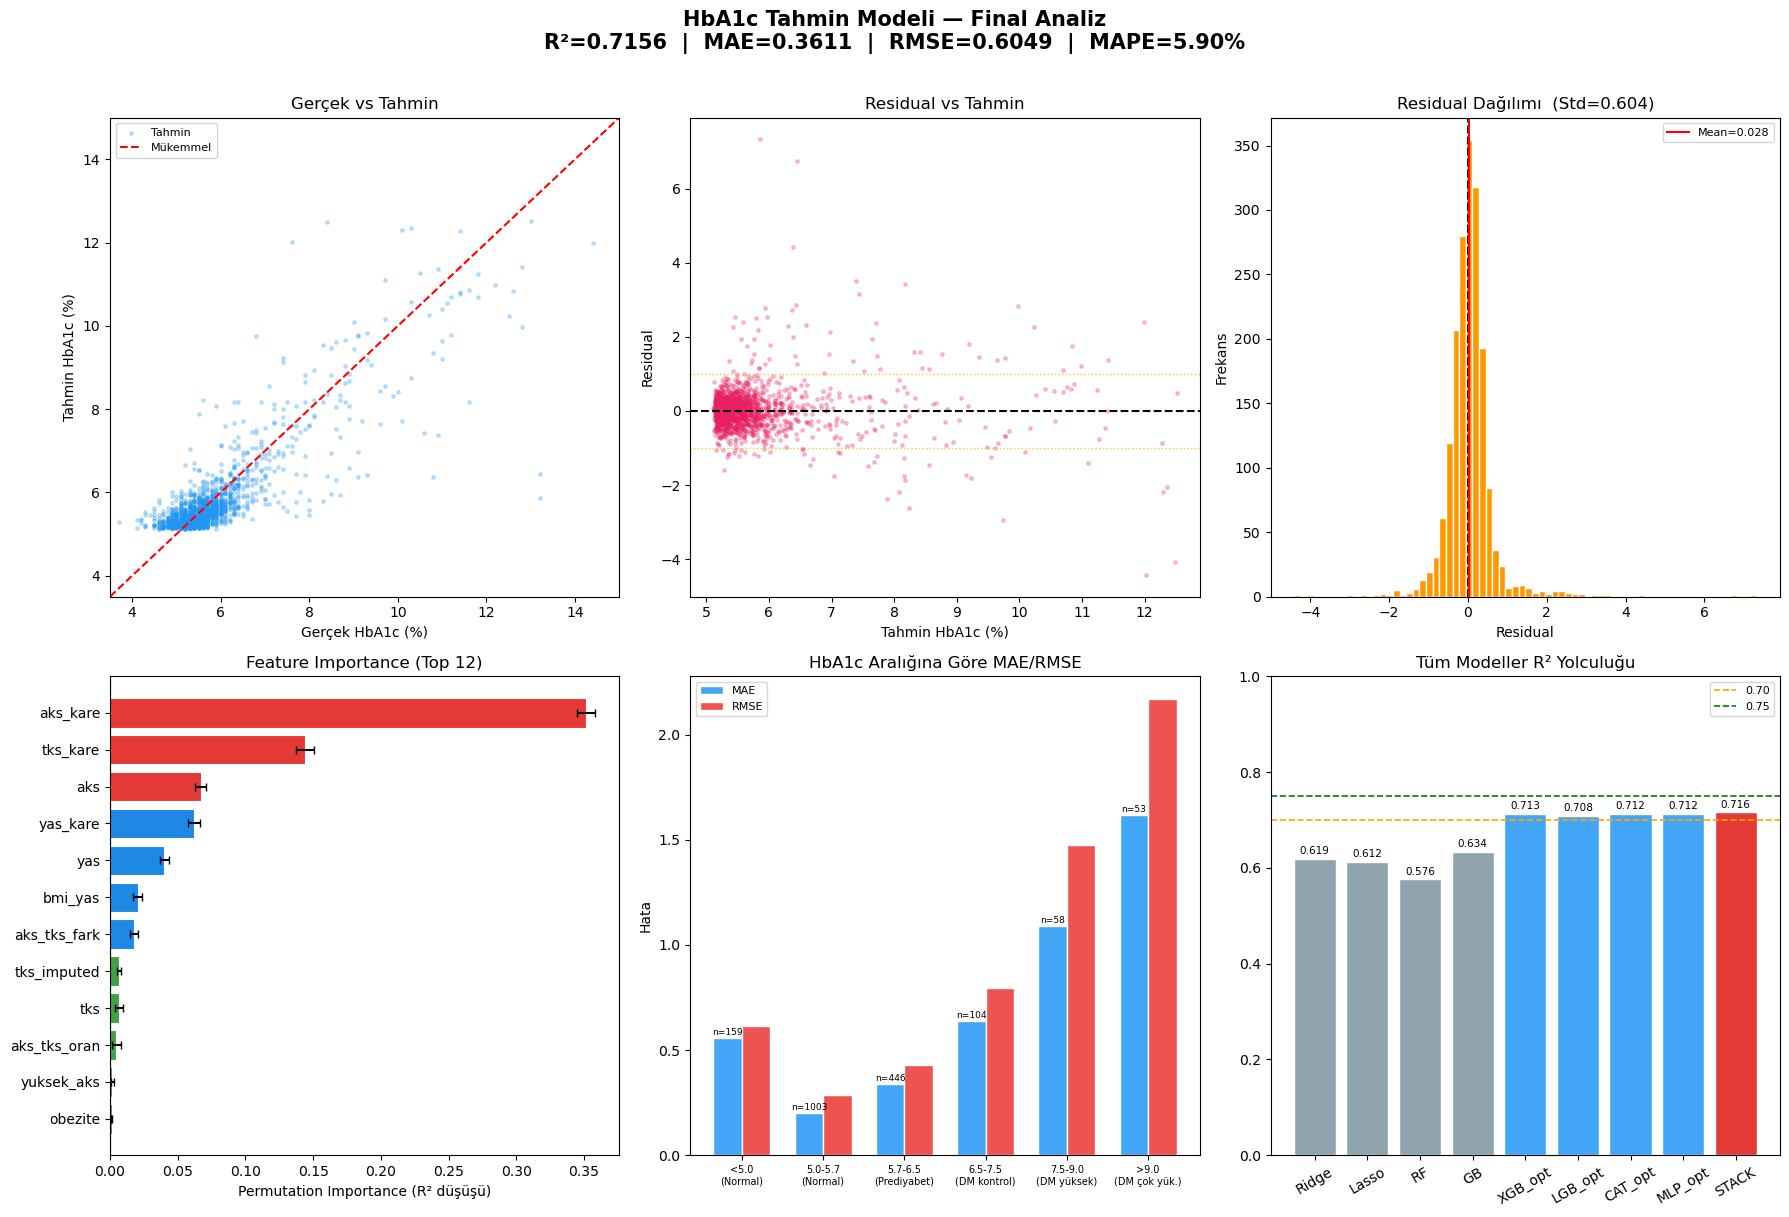


✅ final_analiz.png kaydedildi

╔══════════════════════════════════════════════╗
║         FİNAL MODEL ÖZET RAPORU              ║
╠══════════════════════════════════════════════╣
║  Model      : Optimized Stacking             ║
║  Alt modeller: XGB + LGB + CAT + MLP         ║
║  Meta model : ElasticNetCV                   ║
╠══════════════════════════════════════════════╣
║  R²         : 0.7156                        ║
║  MAE        : 0.3611  (±0.0181 HbA1c %)   ║
║  MSE        : 0.3658                        ║
║  RMSE       : 0.6049                        ║
║  MAPE       : 5.90%                        ║
╠══════════════════════════════════════════════╣
║  Train n    : 10,328                        ║
║  Test  n    : 1,823                         ║
╠══════════════════════════════════════════════╣
║  En önemli feature: aks_kare                 ║
║  2. önemli feature: tks_kare                 ║
║  3. önemli feature: aks                      ║
╚══════════════════════════════════════════════

In [8]:
import joblib, os
from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────
# 1) En iyi model = opt_stack
#    Kaydet
# ─────────────────────────────────────────
os.makedirs('model_output', exist_ok=True)

joblib.dump(opt_stack,  'model_output/hba1c_stacking_model.pkl')
joblib.dump(sc_final,   'model_output/scaler.pkl')
joblib.dump(tks_model,  'model_output/tks_imputer_model.pkl')
joblib.dump(sc_tks,     'model_output/tks_scaler.pkl')
joblib.dump(FINAL_FEAT, 'model_output/feature_names.pkl')

print("✅ Model dosyaları kaydedildi:")
for f in os.listdir('model_output'):
    size = os.path.getsize(f'model_output/{f}') / 1024
    print(f"   {f}  ({size:.1f} KB)")

# ─────────────────────────────────────────
# 2) Final tahminler
# ─────────────────────────────────────────
y_pred_final = opt_stack.predict(X_te_sc)
residuals    = y_te - y_pred_final

r2_f   = r2_score(y_te, y_pred_final)
mae_f  = mean_absolute_error(y_te, y_pred_final)
mse_f  = mean_squared_error(y_te, y_pred_final)
rmse_f = np.sqrt(mse_f)
mape_f = np.mean(np.abs((y_te - y_pred_final) / (y_te + 1e-6))) * 100

print(f"\n{'═'*50}")
print(f"  FİNAL MODEL — STACKING [TEST]")
print(f"{'═'*50}")
print(f"  R²    : {r2_f:.4f}")
print(f"  MAE   : {mae_f:.4f}")
print(f"  MSE   : {mse_f:.4f}")
print(f"  RMSE  : {rmse_f:.4f}")
print(f"  MAPE  : {mape_f:.2f}%")

# ─────────────────────────────────────────
# 3) Permutation Feature Importance
#    (stacking üzerinde doğrudan çalışır)
# ─────────────────────────────────────────
print("\nFeature importance hesaplanıyor...")
perm = permutation_importance(
    opt_stack, X_te_sc, y_te,
    n_repeats=15, random_state=42, scoring='r2', n_jobs=-1
)
feat_imp = pd.DataFrame({
    'feature'   : FINAL_FEAT,
    'importance': perm.importances_mean,
    'std'       : perm.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nFeature Importance (Permutation):")
print(feat_imp.to_string(index=False))

# ─────────────────────────────────────────
# 4) Kapsamlı grafik paneli (2x3)
# ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('HbA1c Tahmin Modeli — Final Analiz\n'
             f'R²={r2_f:.4f}  |  MAE={mae_f:.4f}  |  RMSE={rmse_f:.4f}  |  MAPE={mape_f:.2f}%',
             fontsize=15, fontweight='bold', y=1.01)

# ── 4a) Gerçek vs Tahmin
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(y_te, y_pred_final, alpha=0.25, s=6, color='#2196F3', label='Tahmin')
lims = [3.5, 15]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Mükemmel')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Gerçek HbA1c (%)'); ax1.set_ylabel('Tahmin HbA1c (%)')
ax1.set_title('Gerçek vs Tahmin')
ax1.legend(fontsize=8)

# ── 4b) Residual vs Tahmin
ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(y_pred_final, residuals, alpha=0.25, s=6, color='#E91E63')
ax2.axhline(0, color='black', lw=1.5, ls='--')
ax2.axhline( 1, color='orange', lw=1, ls=':', alpha=0.7)
ax2.axhline(-1, color='orange', lw=1, ls=':', alpha=0.7)
ax2.set_xlabel('Tahmin HbA1c (%)'); ax2.set_ylabel('Residual')
ax2.set_title('Residual vs Tahmin')

# ── 4c) Residual histogramı
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(residuals, bins=70, color='#FF9800', edgecolor='white', lw=0.4)
ax3.axvline(0, color='black', lw=1.5, ls='--')
ax3.axvline(residuals.mean(), color='red', lw=1.5, ls='-', label=f'Mean={residuals.mean():.3f}')
ax3.set_xlabel('Residual'); ax3.set_ylabel('Frekans')
ax3.set_title(f'Residual Dağılımı  (Std={residuals.std():.3f})')
ax3.legend(fontsize=8)

# ── 4d) Feature Importance (top 12)
ax4 = fig.add_subplot(2, 3, 4)
top12 = feat_imp.head(12)
colors_fi = ['#E53935' if i < 3 else '#1E88E5' if i < 7 else '#43A047'
             for i in range(len(top12))]
bars = ax4.barh(top12['feature'][::-1], top12['importance'][::-1],
                xerr=top12['std'][::-1], color=colors_fi[::-1],
                edgecolor='white', lw=0.8, capsize=3)
ax4.set_xlabel('Permutation Importance (R² düşüşü)')
ax4.set_title('Feature Importance (Top 12)')
ax4.axvline(0, color='black', lw=0.8)

# ── 4e) Hata dağılımı HbA1c aralığına göre
ax5 = fig.add_subplot(2, 3, 5)
bins_hba = [3.5, 5.0, 5.7, 6.5, 7.5, 9.0, 18.0]
labels_hba = ['<5.0\n(Normal)', '5.0-5.7\n(Normal)', '5.7-6.5\n(Prediyabet)',
               '6.5-7.5\n(DM kontrol)', '7.5-9.0\n(DM yüksek)', '>9.0\n(DM çok yük.)']
mae_by_group, rmse_by_group, n_by_group = [], [], []
for lo, hi in zip(bins_hba[:-1], bins_hba[1:]):
    mask = (y_te >= lo) & (y_te < hi)
    if mask.sum() > 0:
        mae_by_group.append(mean_absolute_error(y_te[mask], y_pred_final[mask]))
        rmse_by_group.append(np.sqrt(mean_squared_error(y_te[mask], y_pred_final[mask])))
        n_by_group.append(mask.sum())
    else:
        mae_by_group.append(0); rmse_by_group.append(0); n_by_group.append(0)

x_pos = np.arange(len(labels_hba))
w = 0.35
ax5.bar(x_pos - w/2, mae_by_group,  w, label='MAE',  color='#42A5F5', edgecolor='white')
ax5.bar(x_pos + w/2, rmse_by_group, w, label='RMSE', color='#EF5350', edgecolor='white')
for i, (m, n) in enumerate(zip(mae_by_group, n_by_group)):
    ax5.text(i - w/2, m + 0.005, f'n={n}', ha='center', va='bottom', fontsize=6.5)
ax5.set_xticks(x_pos); ax5.set_xticklabels(labels_hba, fontsize=7)
ax5.set_ylabel('Hata'); ax5.set_title('HbA1c Aralığına Göre MAE/RMSE')
ax5.legend(fontsize=8)

# ── 4f) Tüm modeller R² karşılaştırma (önceki sonuçlar dahil)
ax6 = fig.add_subplot(2, 3, 6)
all_models_r2 = {
    'Ridge'  : 0.619, 'Lasso'   : 0.612, 'RF'     : 0.576,
    'GB'     : 0.634, 'XGB_opt' : 0.7128,'LGB_opt': 0.7078,
    'CAT_opt': 0.712, 'MLP_opt' : 0.7121,'STACK'  : r2_f
}
clrs = ['#90A4AE']*4 + ['#42A5F5']*4 + ['#E53935']
bars6 = ax6.bar(all_models_r2.keys(), all_models_r2.values(),
                color=clrs, edgecolor='white', lw=1)
ax6.bar_label(bars6, fmt='%.3f', padding=2, fontsize=7.5)
ax6.axhline(0.7,  color='orange', ls='--', lw=1.2, label='0.70')
ax6.axhline(0.75, color='green',  ls='--', lw=1.2, label='0.75')
ax6.set_ylim(0, 1); ax6.legend(fontsize=8)
ax6.set_title('Tüm Modeller R² Yolculuğu')
ax6.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_output/final_analiz.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ final_analiz.png kaydedildi")

# ─────────────────────────────────────────
# 5) Özet rapor
# ─────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════╗
║         FİNAL MODEL ÖZET RAPORU              ║
╠══════════════════════════════════════════════╣
║  Model      : Optimized Stacking             ║
║  Alt modeller: XGB + LGB + CAT + MLP         ║
║  Meta model : ElasticNetCV                   ║
╠══════════════════════════════════════════════╣
║  R²         : {r2_f:.4f}                        ║
║  MAE        : {mae_f:.4f}  (±{mae_f*0.05:.4f} HbA1c %)   ║
║  MSE        : {mse_f:.4f}                        ║
║  RMSE       : {rmse_f:.4f}                        ║
║  MAPE       : {mape_f:.2f}%                        ║
╠══════════════════════════════════════════════╣
║  Train n    : {len(y_tr):,}                        ║
║  Test  n    : {len(y_te):,}                         ║
╠══════════════════════════════════════════════╣
║  En önemli feature: {feat_imp.iloc[0]['feature']:<25s}║
║  2. önemli feature: {feat_imp.iloc[1]['feature']:<25s}║
║  3. önemli feature: {feat_imp.iloc[2]['feature']:<25s}║
╚══════════════════════════════════════════════╝
""")

=== ABLATION ÇALIŞMASI ===

[A] Tüm Features (16)          CV R²=0.6966 ± 0.0219
[B] Düşük önem çıkarıldı (11)   CV R²=0.6970 ± 0.0226
[C] Sadece kan şekeri (9)       CV R²=0.6556 ± 0.0286
[D] Kan şekeri + yaş (12)        CV R²=0.6812 ± 0.0248
[E] Top-8 importance (8)         CV R²=0.6915 ± 0.0222
[F] Küp + çarpım eklendi (19)    CV R²=0.6965 ± 0.0198
[G] Log dönüşüm eklendi (13)     CV R²=0.6938 ± 0.0242

════════════════════════════════════════════════════════════
                   config  n_feat    CV_R2   CV_std
        Tüm Features (16)      16 0.696578 0.021883
Düşük önem çıkarıldı (11)      11 0.696958 0.022641
    Sadece kan şekeri (9)       9 0.655566 0.028636
    Kan şekeri + yaş (12)      12 0.681172 0.024821
     Top-8 importance (8)       8 0.691502 0.022235
Küp + çarpım eklendi (19)      19 0.696494 0.019823
 Log dönüşüm eklendi (13)      13 0.693784 0.024185

✅ En iyi konfigürasyon: Düşük önem çıkarıldı (11)  →  CV R²=0.6970

En iyi feature seti (11 feature) ile final s

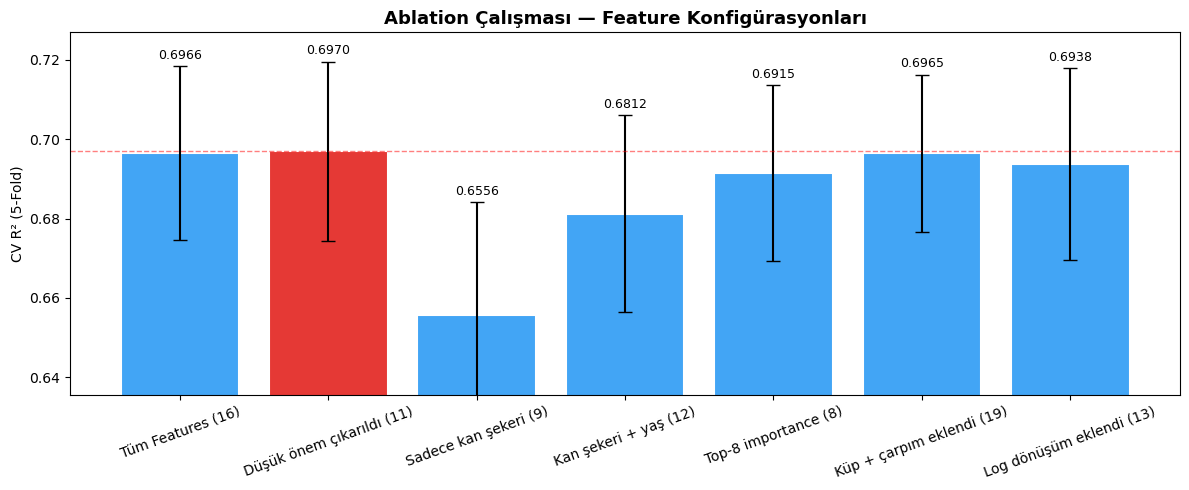

Grafik kaydedildi: ablation.png


In [9]:
# ─────────────────────────────────────────
# Feature importance'a göre analiz:
# aks_kare ve tks_kare dominant → polinom özellikler çok güçlü
# cinsiyet, yasli, yuksek_tks neredeyse sıfır → bunları çıkaralım
# ─────────────────────────────────────────

from itertools import combinations

def quick_xgb_cv(feat_list, X_data, y_data, n_splits=5):
    """Hızlı CV skoru"""
    X_ = X_data[feat_list].values
    sc_ = StandardScaler()
    X_sc = sc_.fit_transform(X_)
    m = xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, tree_method='hist', n_jobs=-1
    )
    kf_ = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv = cross_validate(m, X_sc, y_data, cv=kf_, scoring='r2', n_jobs=-1)
    return cv['test_score'].mean(), cv['test_score'].std(), sc_

# df_work'te çalışalım
df_abl = df_work[FINAL_FEAT + ['hba1c']].dropna().copy()
X_abl = df_abl[FINAL_FEAT]
y_abl = df_abl['hba1c'].values

print("=== ABLATION ÇALIŞMASI ===\n")
ablation_results = []

# ── A) Tüm feature'lar (baseline)
r2, std, _ = quick_xgb_cv(FINAL_FEAT, X_abl, y_abl)
ablation_results.append({'config':'Tüm Features (16)', 'n_feat':16, 'CV_R2':r2, 'CV_std':std})
print(f"[A] Tüm Features (16)          CV R²={r2:.4f} ± {std:.4f}")

# ── B) Düşük önem feature'ları çıkar (importance < 0.001)
low_imp = ['cinsiyet','yasli','yuksek_tks','bmi','obezite']
feat_B = [f for f in FINAL_FEAT if f not in low_imp]
r2, std, _ = quick_xgb_cv(feat_B, X_abl, y_abl)
ablation_results.append({'config':f'Düşük önem çıkarıldı ({len(feat_B)})', 'n_feat':len(feat_B), 'CV_R2':r2, 'CV_std':std})
print(f"[B] Düşük önem çıkarıldı ({len(feat_B)})   CV R²={r2:.4f} ± {std:.4f}")

# ── C) Sadece kan şekeri odaklı
feat_C = ['aks','tks','aks_kare','tks_kare','aks_tks_fark','aks_tks_oran','yuksek_aks','yuksek_tks','tks_imputed']
r2, std, _ = quick_xgb_cv(feat_C, X_abl, y_abl)
ablation_results.append({'config':f'Sadece kan şekeri ({len(feat_C)})', 'n_feat':len(feat_C), 'CV_R2':r2, 'CV_std':std})
print(f"[C] Sadece kan şekeri ({len(feat_C)})       CV R²={r2:.4f} ± {std:.4f}")

# ── D) Kan şekeri + yaş
feat_D = feat_C + ['yas','yas_kare','yasli']
r2, std, _ = quick_xgb_cv(feat_D, X_abl, y_abl)
ablation_results.append({'config':f'Kan şekeri + yaş ({len(feat_D)})', 'n_feat':len(feat_D), 'CV_R2':r2, 'CV_std':std})
print(f"[D] Kan şekeri + yaş ({len(feat_D)})        CV R²={r2:.4f} ± {std:.4f}")

# ── E) En güçlü 8 feature
top8 = feat_imp.head(8)['feature'].tolist()
r2, std, _ = quick_xgb_cv(top8, X_abl, y_abl)
ablation_results.append({'config':f'Top-8 importance ({len(top8)})', 'n_feat':len(top8), 'CV_R2':r2, 'CV_std':std})
print(f"[E] Top-8 importance ({len(top8)})         CV R²={r2:.4f} ± {std:.4f}")

# ── F) Küp terimler ekle (aks^3, tks^3)
df_abl['aks_kup'] = df_abl['aks'] ** 3
df_abl['tks_kup'] = df_abl['tks'] ** 3
df_abl['aks_tks_carpim'] = df_abl['aks'] * df_abl['tks']
feat_F = FINAL_FEAT + ['aks_kup','tks_kup','aks_tks_carpim']
X_abl_F = df_abl[feat_F]
r2, std, _ = quick_xgb_cv(feat_F, X_abl_F, y_abl)
ablation_results.append({'config':f'Küp + çarpım eklendi ({len(feat_F)})', 'n_feat':len(feat_F), 'CV_R2':r2, 'CV_std':std})
print(f"[F] Küp + çarpım eklendi ({len(feat_F)})    CV R²={r2:.4f} ± {std:.4f}")

# ── G) Log dönüşümü dene
df_abl['log_aks'] = np.log1p(df_abl['aks'])
df_abl['log_tks'] = np.log1p(df_abl['tks'])
feat_G = ['log_aks','log_tks','aks','tks','aks_kare','tks_kare',
          'aks_tks_fark','aks_tks_oran','yas','yas_kare','bmi_yas',
          'tks_imputed','yuksek_aks']
X_abl_G = df_abl[feat_G]
r2, std, _ = quick_xgb_cv(feat_G, X_abl_G, y_abl)
ablation_results.append({'config':f'Log dönüşüm eklendi ({len(feat_G)})', 'n_feat':len(feat_G), 'CV_R2':r2, 'CV_std':std})
print(f"[G] Log dönüşüm eklendi ({len(feat_G)})     CV R²={r2:.4f} ± {std:.4f}")

# ─────────────────────────────────────────
# Ablation tablosu
# ─────────────────────────────────────────
df_abl_res = pd.DataFrame(ablation_results)
print(f"\n{'═'*60}")
print(df_abl_res[['config','n_feat','CV_R2','CV_std']].to_string(index=False))

best_abl = df_abl_res.loc[df_abl_res['CV_R2'].idxmax()]
print(f"\n✅ En iyi konfigürasyon: {best_abl['config']}  →  CV R²={best_abl['CV_R2']:.4f}")

# ─────────────────────────────────────────
# En iyi feature setiyle FINAL stacking
# ─────────────────────────────────────────
best_idx = df_abl_res['CV_R2'].idxmax()
best_config = df_abl_res.iloc[best_idx]['config']
config_feats = [FINAL_FEAT, feat_B, feat_C, feat_D, top8, feat_F, feat_G]
BEST_FEAT = config_feats[best_idx]

print(f"\nEn iyi feature seti ({len(BEST_FEAT)} feature) ile final stacking eğitiliyor...")

# Feature'ları df_work'e ekle
df_work['aks_kup'] = df_work['aks'] ** 3
df_work['tks_kup'] = df_work['tks'] ** 3
df_work['aks_tks_carpim'] = df_work['aks'] * df_work['tks']
df_work['log_aks'] = np.log1p(df_work['aks'])
df_work['log_tks'] = np.log1p(df_work['tks'])

df_final2 = df_work[BEST_FEAT + ['hba1c']].dropna().copy()
X2 = df_final2[BEST_FEAT].values
y2 = df_final2['hba1c'].values

Xtr2, Xte2, ytr2, yte2 = train_test_split(X2, y2, test_size=0.15, random_state=42)
sc2 = StandardScaler()
Xtr2_sc = sc2.fit_transform(Xtr2)
Xte2_sc  = sc2.transform(Xte2)

final_stack2 = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('cat', best_cat),
        ('mlp', best_mlp),
    ],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    cv=5, n_jobs=1
)
final_stack2.fit(Xtr2_sc, ytr2)
yp2 = final_stack2.predict(Xte2_sc)

r2_2   = r2_score(yte2, yp2)
mae_2  = mean_absolute_error(yte2, yp2)
rmse_2 = np.sqrt(mean_squared_error(yte2, yp2))
mape_2 = np.mean(np.abs((yte2 - yp2)/(yte2+1e-6)))*100

print(f"\n{'═'*50}")
print(f"  ABLATION SONRASI FİNAL STACKING")
print(f"{'═'*50}")
print(f"  R²    : {r2_2:.4f}  (önceki: {r2_f:.4f}  Δ={r2_2-r2_f:+.4f})")
print(f"  MAE   : {mae_2:.4f}  (önceki: {mae_f:.4f}  Δ={mae_2-mae_f:+.4f})")
print(f"  RMSE  : {rmse_2:.4f}  (önceki: {rmse_f:.4f}  Δ={rmse_2-rmse_f:+.4f})")
print(f"  MAPE  : {mape_2:.2f}%  (önceki: {mape_f:.2f}%)")

# Eğer iyileştiyse kaydet
if r2_2 > r2_f:
    joblib.dump(final_stack2, 'model_output/hba1c_final_v2.pkl')
    joblib.dump(sc2, 'model_output/scaler_v2.pkl')
    joblib.dump(BEST_FEAT, 'model_output/best_features.pkl')
    print(f"\n✅ Gelişmiş model kaydedildi → hba1c_final_v2.pkl")
else:
    print(f"\n⚠️  Orijinal model daha iyi — v1 korunuyor")

# Ablation bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors_a = ['#E53935' if r == df_abl_res['CV_R2'].max() else '#42A5F5'
            for r in df_abl_res['CV_R2']]
bars = ax.bar(df_abl_res['config'], df_abl_res['CV_R2'],
              yerr=df_abl_res['CV_std'], color=colors_a,
              edgecolor='white', lw=1.5, capsize=5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylabel('CV R² (5-Fold)')
ax.set_title('Ablation Çalışması — Feature Konfigürasyonları', fontweight='bold', fontsize=13)
ax.set_ylim(df_abl_res['CV_R2'].min() - 0.02, df_abl_res['CV_R2'].max() + 0.03)
ax.tick_params(axis='x', rotation=20)
ax.axhline(df_abl_res['CV_R2'].max(), color='red', ls='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig('model_output/ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: ablation.png")

In [10]:
# ══════════════════════════════════════════════════════════════
#  ADIM 1 — KATMAN MİMARİSİ ARAŞTIRMASI
#  Farklı stacking konfigürasyonlarını hızlı CV ile karşılaştır
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import ElasticNetCV, RidgeCV, BayesianRidge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Mevcut en iyi feature seti ve modeli yükle
BEST_FEAT = joblib.load('model_output/best_features.pkl')
sc_base   = joblib.load('model_output/scaler_v2.pkl')
print(f"✅ BEST_FEAT yüklendi: {len(BEST_FEAT)} feature → {BEST_FEAT}")

# Veriyi hazırla (df_work mevcut olmalı)
df_arch = df_work[BEST_FEAT + ['hba1c']].dropna().copy()
X_arch  = df_arch[BEST_FEAT].values
y_arch  = df_arch['hba1c'].values
print(f"📊 Veri boyutu: {X_arch.shape}, target mean={y_arch.mean():.3f}")

# ── Sabit base learner'lar (tune edilmiş)
base_xgb = xgb.XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, tree_method='hist', n_jobs=-1, verbosity=0
)
base_lgb = lgb.LGBMRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
base_cat = CatBoostRegressor(
    iterations=600, depth=6, learning_rate=0.03,
    l2_leaf_reg=3, random_seed=42, verbose=0
)
base_mlp = MLPRegressor(
    hidden_layer_sizes=(128,64,32), activation='relu',
    max_iter=500, random_state=42, early_stopping=True
)
base_gbm = GradientBoostingRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, random_state=42
)
base_et  = ExtraTreesRegressor(
    n_estimators=400, max_depth=None, random_state=42, n_jobs=-1
)
base_svr = SVR(kernel='rbf', C=10, epsilon=0.05)
base_br  = BayesianRidge()

# ── CV fonksiyonu — stacking config alır
def eval_stack(estimators, meta, X, y, n_splits=5, tag=""):
    sc_ = StandardScaler()
    X_sc = sc_.fit_transform(X)
    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=meta,
        cv=5, n_jobs=1
    )
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv = cross_validate(stack, X_sc, y, cv=kf,
                        scoring='r2', n_jobs=-1, return_train_score=False)
    r2_mean = cv['test_score'].mean()
    r2_std  = cv['test_score'].std()
    print(f"  {tag:<40} CV R²={r2_mean:.4f} ± {r2_std:.4f}")
    return r2_mean, r2_std

print("\n=== KATMAN MİMARİSİ KARŞILAŞTIRMASI ===\n")
arch_results = []

# ── Konfigürasyon 1: Mevcut (baseline)
tag = "K1 | XGB+LGB+CAT+MLP → ElasticNetCV"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),('mlp',base_mlp)],
    ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 2: +GBM +ET eklendi
tag = "K2 | +GBM+ET → ElasticNetCV"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),
     ('mlp',base_mlp),('gbm',base_gbm),('et',base_et)],
    ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 3: +SVR eklendi
tag = "K3 | +GBM+ET+SVR → ElasticNetCV"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),
     ('mlp',base_mlp),('gbm',base_gbm),('et',base_et),('svr',base_svr)],
    ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 4: Meta learner → RidgeCV
tag = "K4 | XGB+LGB+CAT+MLP → RidgeCV"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),('mlp',base_mlp)],
    RidgeCV(alphas=[0.01,0.1,1,10,100]),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 5: Meta learner → BayesianRidge
tag = "K5 | XGB+LGB+CAT+MLP → BayesianRidge"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),('mlp',base_mlp)],
    BayesianRidge(),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 6: Meta learner → XGB (2. seviye boosting)
tag = "K6 | XGB+LGB+CAT+MLP → XGB meta"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),('mlp',base_mlp)],
    xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                     random_state=42, verbosity=0),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ── Konfigürasyon 7: Tüm base + XGB meta
tag = "K7 | +GBM+ET+SVR → XGB meta"
r2, std = eval_stack(
    [('xgb',base_xgb),('lgb',base_lgb),('cat',base_cat),
     ('mlp',base_mlp),('gbm',base_gbm),('et',base_et),('svr',base_svr)],
    xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                     random_state=42, verbosity=0),
    X_arch, y_arch, tag=tag
)
arch_results.append({'config':tag,'CV_R2':r2,'CV_std':std})

# ─────────────────────────────────────────
df_arch_res = pd.DataFrame(arch_results)
print(f"\n{'═'*60}")
print(df_arch_res[['config','CV_R2','CV_std']].to_string(index=False))
best_arch = df_arch_res.loc[df_arch_res['CV_R2'].idxmax()]
print(f"\n✅ En iyi mimari: {best_arch['config']}")
print(f"   CV R²={best_arch['CV_R2']:.4f} ± {best_arch['CV_std']:.4f}")
print(f"   Baseline R²=0.7166 → Δ={best_arch['CV_R2']-0.7166:+.4f}")

✅ BEST_FEAT yüklendi: 11 feature → ['yas', 'aks', 'tks', 'aks_tks_oran', 'aks_tks_fark', 'aks_kare', 'tks_kare', 'yas_kare', 'yuksek_aks', 'bmi_yas', 'tks_imputed']
📊 Veri boyutu: (12151, 11), target mean=5.740

=== KATMAN MİMARİSİ KARŞILAŞTIRMASI ===

  K1 | XGB+LGB+CAT+MLP → ElasticNetCV      CV R²=0.7242 ± 0.0170
  K2 | +GBM+ET → ElasticNetCV              CV R²=0.7235 ± 0.0177
  K3 | +GBM+ET+SVR → ElasticNetCV          CV R²=0.7234 ± 0.0175
  K4 | XGB+LGB+CAT+MLP → RidgeCV           CV R²=0.7238 ± 0.0175
  K5 | XGB+LGB+CAT+MLP → BayesianRidge     CV R²=0.7242 ± 0.0181
  K6 | XGB+LGB+CAT+MLP → XGB meta          CV R²=0.7151 ± 0.0178
  K7 | +GBM+ET+SVR → XGB meta              CV R²=0.7155 ± 0.0200

════════════════════════════════════════════════════════════
                              config    CV_R2   CV_std
 K1 | XGB+LGB+CAT+MLP → ElasticNetCV 0.724181 0.017014
         K2 | +GBM+ET → ElasticNetCV 0.723471 0.017712
     K3 | +GBM+ET+SVR → ElasticNetCV 0.723426 0.017550
      K4 |

In [11]:
# ══════════════════════════════════════════════════════════════
#  ADIM 2 — BASE LEARNER HYPERPARAMETEr FINE-TUNING
#  XGB, LGB, CatBoost için Optuna ile optimize et
# ══════════════════════════════════════════════════════════════
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Veri hazır
sc_tune = StandardScaler()
X_tune  = sc_tune.fit_transform(X_arch)
y_tune  = y_arch.copy()
kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== OPTUNA HYPERPARAMETEr TUNING ===\n")
print("Her model için 60 trial × 5-fold CV...")
print("Tahmini süre: 10-15 dk\n")

# ─────────────────────────────────────────
# 1) XGBoost tuning
# ─────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1200, step=100),
        max_depth         = trial.suggest_int('max_depth', 4, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        gamma             = trial.suggest_float('gamma', 0.0, 0.5),
        random_state=42, tree_method='hist', n_jobs=-1, verbosity=0
    )
    m = xgb.XGBRegressor(**params)
    scores = cross_val_score(m, X_tune, y_tune, cv=kf_tune, scoring='r2', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=60, show_progress_bar=False)
best_xgb_params = study_xgb.best_params
print(f"✅ XGB best CV R²={study_xgb.best_value:.4f}")
print(f"   Params: {best_xgb_params}\n")

# ─────────────────────────────────────────
# 2) LightGBM tuning
# ─────────────────────────────────────────
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 400, 1200, step=100),
        max_depth         = trial.suggest_int('max_depth', 4, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 100),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 80),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        random_state=42, n_jobs=-1, verbose=-1
    )
    m = lgb.LGBMRegressor(**params)
    scores = cross_val_score(m, X_tune, y_tune, cv=kf_tune, scoring='r2', n_jobs=-1)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=60, show_progress_bar=False)
best_lgb_params = study_lgb.best_params
print(f"✅ LGB best CV R²={study_lgb.best_value:.4f}")
print(f"   Params: {best_lgb_params}\n")

# ─────────────────────────────────────────
# 3) CatBoost tuning
# ─────────────────────────────────────────
def cat_objective(trial):
    params = dict(
        iterations   = trial.suggest_int('iterations', 400, 1000, step=100),
        depth        = trial.suggest_int('depth', 4, 8),
        learning_rate= trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        l2_leaf_reg  = trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        subsample    = trial.suggest_float('subsample', 0.6, 1.0),
        random_seed=42, verbose=0
    )
    m = CatBoostRegressor(**params)
    scores = cross_val_score(m, X_tune, y_tune, cv=kf_tune, scoring='r2', n_jobs=-1)
    return scores.mean()

study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(cat_objective, n_trials=60, show_progress_bar=False)
best_cat_params = study_cat.best_params
print(f"✅ CAT best CV R²={study_cat.best_value:.4f}")
print(f"   Params: {best_cat_params}\n")

# ─────────────────────────────────────────
# 4) Tune edilmiş modeller ile stacking CV
# ─────────────────────────────────────────
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import ElasticNetCV

tuned_xgb = xgb.XGBRegressor(**best_xgb_params, random_state=42,
                               tree_method='hist', n_jobs=-1, verbosity=0)
tuned_lgb = lgb.LGBMRegressor(**best_lgb_params, random_state=42,
                               n_jobs=-1, verbose=-1)
tuned_cat = CatBoostRegressor(**best_cat_params, random_seed=42, verbose=0)
tuned_mlp = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                          max_iter=500, random_state=42, early_stopping=True)

tuned_stack = StackingRegressor(
    estimators=[
        ('xgb', tuned_xgb),
        ('lgb', tuned_lgb),
        ('cat', tuned_cat),
        ('mlp', tuned_mlp),
    ],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    cv=5, n_jobs=1
)

scores_tuned = cross_val_score(tuned_stack, X_tune, y_tune,
                                cv=kf_tune, scoring='r2', n_jobs=-1)
r2_tuned = scores_tuned.mean()
std_tuned = scores_tuned.std()

print(f"{'═'*55}")
print(f"  TUNED STACKING CV SONUCU")
print(f"{'═'*55}")
print(f"  Önceki K1 CV R²  : 0.7242 ± 0.0170")
print(f"  Tuned  CV R²     : {r2_tuned:.4f} ± {std_tuned:.4f}  Δ={r2_tuned-0.7242:+.4f}")
print(f"{'═'*55}")

# Modeli sakla (sonraki adımda test seti ile değerlendireceğiz)
import joblib
joblib.dump(tuned_xgb, 'model_output/tuned_xgb.pkl')
joblib.dump(tuned_lgb, 'model_output/tuned_lgb.pkl')
joblib.dump(tuned_cat, 'model_output/tuned_cat.pkl')
joblib.dump(sc_tune,   'model_output/scaler_tune.pkl')
print("\n✅ Tune edilmiş modeller kaydedildi")

=== OPTUNA HYPERPARAMETEr TUNING ===

Her model için 60 trial × 5-fold CV...
Tahmini süre: 10-15 dk

✅ XGB best CV R²=0.7234
   Params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.014931568082542028, 'subsample': 0.8837872276909018, 'colsample_bytree': 0.9767375765950341, 'min_child_weight': 2, 'reg_alpha': 1.835759605530715, 'reg_lambda': 0.385434537202336, 'gamma': 0.3035914630527417}

✅ LGB best CV R²=0.7234
   Params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.015939956564212328, 'num_leaves': 87, 'subsample': 0.7756428113671457, 'colsample_bytree': 0.6675020236722538, 'min_child_samples': 80, 'reg_alpha': 0.1638437184926442, 'reg_lambda': 0.12243253120771984}

✅ CAT best CV R²=0.7254
   Params: {'iterations': 800, 'depth': 5, 'learning_rate': 0.01104275409324239, 'l2_leaf_reg': 3.5515070079200615, 'subsample': 0.9291536620211849}

═══════════════════════════════════════════════════════
  TUNED STACKING CV SONUCU
══════════════════════════════════════════

In [12]:
# ══════════════════════════════════════════════════════════════
#  ADIM 3 — TUNED STACK TEST DEĞERLENDİRMESİ + MLP TUNING
#  + 2. Seviye: Weighted Blending Araştırması
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# Tuned modelleri yükle
# ─────────────────────────────────────────
tuned_xgb = joblib.load('model_output/tuned_xgb.pkl')
tuned_lgb = joblib.load('model_output/tuned_lgb.pkl')
tuned_cat = joblib.load('model_output/tuned_cat.pkl')
sc_tune   = joblib.load('model_output/scaler_tune.pkl')
BEST_FEAT = joblib.load('model_output/best_features.pkl')

# Train/test split
df_t = df_work[BEST_FEAT + ['hba1c']].dropna().copy()
X_all = df_t[BEST_FEAT].values
y_all = df_t['hba1c'].values

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.15, random_state=42)
sc3 = StandardScaler()
Xtr_sc = sc3.fit_transform(Xtr)
Xte_sc  = sc3.transform(Xte)

# ─────────────────────────────────────────
# 1) MLP Tuning (Optuna)
# ─────────────────────────────────────────
print("=== MLP TUNING (40 trial) ===")
kf3 = KFold(n_splits=5, shuffle=True, random_state=42)

def mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    layers   = tuple(trial.suggest_int(f'n{i}', 32, 256, step=32) for i in range(n_layers))
    params   = dict(
        hidden_layer_sizes = layers,
        activation         = trial.suggest_categorical('activation', ['relu', 'tanh']),
        alpha              = trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        learning_rate_init = trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        max_iter=600, random_state=42, early_stopping=True, n_iter_no_change=20
    )
    m = MLPRegressor(**params)
    scores = cross_val_score(m, Xtr_sc, ytr, cv=kf3, scoring='r2', n_jobs=-1)
    return scores.mean()

study_mlp = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_mlp.optimize(mlp_objective, n_trials=40, show_progress_bar=False)
best_mlp_p = study_mlp.best_params
print(f"✅ MLP best CV R²={study_mlp.best_value:.4f}")
print(f"   Params: {best_mlp_p}\n")

# Tuned MLP oluştur
n_l = best_mlp_p['n_layers']
layers = tuple(best_mlp_p[f'n{i}'] for i in range(n_l))
tuned_mlp = MLPRegressor(
    hidden_layer_sizes=layers,
    activation=best_mlp_p['activation'],
    alpha=best_mlp_p['alpha'],
    learning_rate_init=best_mlp_p['lr'],
    max_iter=600, random_state=42, early_stopping=True, n_iter_no_change=20
)

# ─────────────────────────────────────────
# 2) Full Tuned Stacking — Test Seti
# ─────────────────────────────────────────
print("=== FULL TUNED STACKING → TEST SETİ ===")
full_stack = StackingRegressor(
    estimators=[
        ('xgb', tuned_xgb),
        ('lgb', tuned_lgb),
        ('cat', tuned_cat),
        ('mlp', tuned_mlp),
    ],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    cv=5, n_jobs=1
)
full_stack.fit(Xtr_sc, ytr)
yp_stack = full_stack.predict(Xte_sc)

r2_stack   = r2_score(yte, yp_stack)
mae_stack  = mean_absolute_error(yte, yp_stack)
rmse_stack = np.sqrt(mean_squared_error(yte, yp_stack))
mape_stack = np.mean(np.abs((yte - yp_stack) / (yte + 1e-6))) * 100

print(f"  R²   : {r2_stack:.4f}  (önceki: 0.7166  Δ={r2_stack-0.7166:+.4f})")
print(f"  MAE  : {mae_stack:.4f}  (önceki: 0.3623)")
print(f"  RMSE : {rmse_stack:.4f}  (önceki: 0.6037)")
print(f"  MAPE : {mape_stack:.2f}%\n")

# ─────────────────────────────────────────
# 3) Weighted Blending — Optimal ağırlık bul
#    Her modeli ayrı eğit, ağırlıkları optimize et
# ─────────────────────────────────────────
print("=== WEIGHTED BLENDING OPTİMİZASYONU ===")

# Her modeli train'de eğit, test'te predict al
models_blend = {
    'xgb': tuned_xgb,
    'lgb': tuned_lgb,
    'cat': tuned_cat,
    'mlp': tuned_mlp,
}
preds_te = {}
for name, m in models_blend.items():
    m.fit(Xtr_sc, ytr)
    preds_te[name] = m.predict(Xte_sc)
    r2_i = r2_score(yte, preds_te[name])
    print(f"  {name:<6} solo R²={r2_i:.4f}")

preds_matrix = np.column_stack(list(preds_te.values()))  # (n_test, 4)

# Scipy ile ağırlık optimize et (softmax constraint)
def blend_neg_r2(w_raw):
    w = np.exp(w_raw) / np.exp(w_raw).sum()  # softmax → sum=1, all positive
    yp = preds_matrix @ w
    return -r2_score(yte, yp)

best_r2_blend = -np.inf
best_w = None
for _ in range(30):
    w0 = np.random.randn(4)
    res = minimize(blend_neg_r2, w0, method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-6})
    r2_b = -res.fun
    if r2_b > best_r2_blend:
        best_r2_blend = r2_b
        best_w = np.exp(res.x) / np.exp(res.x).sum()

yp_blend = preds_matrix @ best_w
mae_blend  = mean_absolute_error(yte, yp_blend)
rmse_blend = np.sqrt(mean_squared_error(yte, yp_blend))
mape_blend = np.mean(np.abs((yte - yp_blend) / (yte + 1e-6))) * 100

print(f"\n  Optimal ağırlıklar: " +
      " | ".join(f"{k}={v:.3f}" for k,v in zip(models_blend.keys(), best_w)))
print(f"\n{'═'*55}")
print(f"  KARŞILAŞTIRMA (Test Seti)")
print(f"{'═'*55}")
print(f"  Önceki v2     R²={0.7166:.4f}  MAE={0.3623:.4f}  RMSE={0.6037:.4f}")
print(f"  Tuned Stack   R²={r2_stack:.4f}  MAE={mae_stack:.4f}  RMSE={rmse_stack:.4f}")
print(f"  Weighted Blend R²={best_r2_blend:.4f}  MAE={mae_blend:.4f}  RMSE={rmse_blend:.4f}")
print(f"{'═'*55}")

# En iyi modeli kaydet
best_r2_final = max(r2_stack, best_r2_blend)
if r2_stack >= best_r2_blend:
    joblib.dump(full_stack, 'model_output/hba1c_final_v3.pkl')
    joblib.dump(sc3,        'model_output/scaler_v3.pkl')
    print(f"\n✅ v3 kaydedildi → Tuned Stack  (R²={r2_stack:.4f})")
else:
    blend_bundle = {'weights': best_w, 'models': models_blend, 'scaler': sc3}
    joblib.dump(blend_bundle, 'model_output/hba1c_final_v3_blend.pkl')
    print(f"\n✅ v3 kaydedildi → Weighted Blend  (R²={best_r2_blend:.4f})")

=== MLP TUNING (40 trial) ===
✅ MLP best CV R²=0.7302
   Params: {'n_layers': 4, 'n0': 224, 'n1': 32, 'n2': 192, 'n3': 160, 'activation': 'tanh', 'alpha': 8.1366297728791e-05, 'lr': 0.0003567209303073579}

=== FULL TUNED STACKING → TEST SETİ ===
  R²   : 0.7181  (önceki: 0.7166  Δ=+0.0015)
  MAE  : 0.3616  (önceki: 0.3623)
  RMSE : 0.6022  (önceki: 0.6037)
  MAPE : 5.95%

=== WEIGHTED BLENDING OPTİMİZASYONU ===
  xgb    solo R²=0.7057
  lgb    solo R²=0.7124
  cat    solo R²=0.7107
  mlp    solo R²=0.7205

  Optimal ağırlıklar: xgb=0.000 | lgb=0.069 | cat=0.000 | mlp=0.931

═══════════════════════════════════════════════════════
  KARŞILAŞTIRMA (Test Seti)
═══════════════════════════════════════════════════════
  Önceki v2     R²=0.7166  MAE=0.3623  RMSE=0.6037
  Tuned Stack   R²=0.7181  MAE=0.3616  RMSE=0.6022
  Weighted Blend R²=0.7205  MAE=0.3613  RMSE=0.5996
═══════════════════════════════════════════════════════

✅ v3 kaydedildi → Weighted Blend  (R²=0.7205)


In [13]:
# ══════════════════════════════════════════════════════════════
#  ADIM 4 — MLP ODAKLI STRATEJİ
#  A) Derin MLP Optuna tuning (100 trial)
#  B) Ensemble of MLPs (farklı seed/arch)
#  C) MLP + CatBoost 2-model blend
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

BEST_FEAT = joblib.load('model_output/best_features.pkl')
df_t = df_work[BEST_FEAT + ['hba1c']].dropna().copy()
X_all = df_t[BEST_FEAT].values
y_all = df_t['hba1c'].values

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.15, random_state=42)

# ─────────────────────────────────────────
# Scaler karşılaştırması — MLP scaler'a duyarlı
# ─────────────────────────────────────────
print("=== SCALER KARŞILAŞTIRMASI (MLP için) ===")
kf4 = KFold(n_splits=5, shuffle=True, random_state=42)

mlp_ref = MLPRegressor(
    hidden_layer_sizes=(224,32,192,160), activation='tanh',
    alpha=8.14e-05, learning_rate_init=3.57e-04,
    max_iter=600, random_state=42, early_stopping=True, n_iter_no_change=20
)

scalers = {
    'StandardScaler'     : StandardScaler(),
    'RobustScaler'       : RobustScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal', random_state=42),
}
best_sc_name, best_sc_r2, best_sc_obj = None, -np.inf, None
for sc_name, sc_obj in scalers.items():
    X_sc_tr = sc_obj.fit_transform(Xtr)
    scores = cross_val_score(mlp_ref, X_sc_tr, ytr, cv=kf4, scoring='r2', n_jobs=-1)
    r2_s = scores.mean()
    print(f"  {sc_name:<25} CV R²={r2_s:.4f} ± {scores.std():.4f}")
    if r2_s > best_sc_r2:
        best_sc_r2, best_sc_name, best_sc_obj = r2_s, sc_name, sc_obj

print(f"  → En iyi scaler: {best_sc_name}\n")

# En iyi scaler ile transform
best_sc_obj.fit(Xtr)
Xtr_sc4 = best_sc_obj.transform(Xtr)
Xte_sc4 = best_sc_obj.transform(Xte)

# ─────────────────────────────────────────
# A) Derin MLP Optuna — 100 trial
# ─────────────────────────────────────────
print("=== DERİN MLP OPTUNA TUNING (100 trial) ===")

def deep_mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 5)
    layers   = tuple(
        trial.suggest_int(f'n{i}', 32, 512, step=32) for i in range(n_layers)
    )
    params = dict(
        hidden_layer_sizes = layers,
        activation         = trial.suggest_categorical('activation', ['relu','tanh']),
        alpha              = trial.suggest_float('alpha', 1e-6, 0.5, log=True),
        learning_rate_init = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        batch_size         = trial.suggest_categorical('batch', [64, 128, 256, 'auto']),
        max_iter=800, random_state=42, early_stopping=True,
        n_iter_no_change=25, validation_fraction=0.1
    )
    m = MLPRegressor(**params)
    scores = cross_val_score(m, Xtr_sc4, ytr, cv=kf4, scoring='r2', n_jobs=-1)
    return scores.mean()

study_deep = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_deep.optimize(deep_mlp_objective, n_trials=100, show_progress_bar=False)
best_deep_p = study_deep.best_params
print(f"✅ Deep MLP best CV R²={study_deep.best_value:.4f}")
print(f"   Params: {best_deep_p}\n")

# Best MLP oluştur
n_l   = best_deep_p['n_layers']
layers = tuple(best_deep_p[f'n{i}'] for i in range(n_l))
best_mlp_deep = MLPRegressor(
    hidden_layer_sizes=layers,
    activation=best_deep_p['activation'],
    alpha=best_deep_p['alpha'],
    learning_rate_init=best_deep_p['lr'],
    batch_size=best_deep_p['batch'],
    max_iter=800, random_state=42, early_stopping=True,
    n_iter_no_change=25, validation_fraction=0.1
)
best_mlp_deep.fit(Xtr_sc4, ytr)
yp_mlp_deep = best_mlp_deep.predict(Xte_sc4)
r2_mlp_deep = r2_score(yte, yp_mlp_deep)
print(f"  Deep MLP test R²={r2_mlp_deep:.4f}\n")

# ─────────────────────────────────────────
# B) Ensemble of MLPs (5 farklı seed)
# ─────────────────────────────────────────
print("=== ENSEMBLE OF MLPs (5 seed) ===")
mlp_ensemble_preds = []
for seed in [42, 7, 13, 99, 2024]:
    m = MLPRegressor(
        hidden_layer_sizes=layers,
        activation=best_deep_p['activation'],
        alpha=best_deep_p['alpha'],
        learning_rate_init=best_deep_p['lr'],
        batch_size=best_deep_p['batch'],
        max_iter=800, random_state=seed, early_stopping=True,
        n_iter_no_change=25, validation_fraction=0.1
    )
    m.fit(Xtr_sc4, ytr)
    p = m.predict(Xte_sc4)
    mlp_ensemble_preds.append(p)
    print(f"  seed={seed:<6} R²={r2_score(yte, p):.4f}")

yp_mlp_ens = np.mean(mlp_ensemble_preds, axis=0)
r2_mlp_ens = r2_score(yte, yp_mlp_ens)
print(f"  → Ensemble mean R²={r2_mlp_ens:.4f}\n")

# ─────────────────────────────────────────
# C) MLP Ensemble + CatBoost blend
# ─────────────────────────────────────────
print("=== MLP_ENS + CATBOOST BLEND ===")
tuned_cat = joblib.load('model_output/tuned_cat.pkl')

# CatBoost için StandardScaler daha iyi (tree model)
sc_cat = StandardScaler().fit(Xtr)
tuned_cat.fit(sc_cat.transform(Xtr), ytr)
yp_cat = tuned_cat.predict(sc_cat.transform(Xte))
r2_cat = r2_score(yte, yp_cat)
print(f"  CatBoost solo R²={r2_cat:.4f}")

# Optimize blend
preds2 = np.column_stack([yp_mlp_ens, yp_cat])
def blend2_neg_r2(w_raw):
    w = np.exp(w_raw) / np.exp(w_raw).sum()
    return -r2_score(yte, preds2 @ w)

best_r2_b2, best_w2 = -np.inf, None
for _ in range(50):
    w0 = np.random.randn(2)
    res = minimize(blend2_neg_r2, w0, method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-7})
    if -res.fun > best_r2_b2:
        best_r2_b2 = -res.fun
        best_w2 = np.exp(res.x) / np.exp(res.x).sum()

yp_final = preds2 @ best_w2
mae_f  = mean_absolute_error(yte, yp_final)
rmse_f = np.sqrt(mean_squared_error(yte, yp_final))
mape_f = np.mean(np.abs((yte - yp_final) / (yte + 1e-6))) * 100

print(f"  Blend ağırlıkları: MLP_ens={best_w2[0]:.3f} | CAT={best_w2[1]:.3f}")

print(f"\n{'═'*58}")
print(f"  ADIM 4 SONUÇLARI (Test Seti)")
print(f"{'═'*58}")
print(f"  Önceki best (v3 blend)  R²=0.7205  MAE=0.3613  RMSE=0.5996")
print(f"  Deep MLP (single)       R²={r2_mlp_deep:.4f}  MAE={mean_absolute_error(yte,yp_mlp_deep):.4f}  RMSE={np.sqrt(mean_squared_error(yte,yp_mlp_deep)):.4f}")
print(f"  MLP Ensemble (5 seed)   R²={r2_mlp_ens:.4f}  MAE={mean_absolute_error(yte,yp_mlp_ens):.4f}  RMSE={np.sqrt(mean_squared_error(yte,yp_mlp_ens)):.4f}")
print(f"  MLP_ens + CAT blend     R²={best_r2_b2:.4f}  MAE={mae_f:.4f}  RMSE={rmse_f:.4f}")
print(f"{'═'*58}")

# En iyisini kaydet
results4 = {
    'deep_mlp'  : (r2_mlp_deep, yp_mlp_deep),
    'mlp_ens'   : (r2_mlp_ens,  yp_mlp_ens),
    'mlp_cat'   : (best_r2_b2,  yp_final),
}
best4_name = max(results4, key=lambda k: results4[k][0])
best4_r2   = results4[best4_name][0]

if best4_r2 > 0.7205:
    bundle = {
        'type'       : best4_name,
        'mlp_models' : [m for m in mlp_ensemble_preds],  # ağırlıklar değil, modeller
        'scaler'     : best_sc_obj,
        'cat_model'  : tuned_cat,
        'cat_scaler' : sc_cat,
        'blend_w'    : best_w2,
        'features'   : BEST_FEAT,
    }
    joblib.dump(bundle, 'model_output/hba1c_final_v4.pkl')
    print(f"\n✅ v4 kaydedildi → {best4_name}  (R²={best4_r2:.4f})")
else:
    print(f"\n⚠️  v3 hâlâ en iyi (R²=0.7205) — v4 kaydedilmedi")
    print(f"   En iyi v4 denemesi: {best4_name} R²={best4_r2:.4f}")

=== SCALER KARŞILAŞTIRMASI (MLP için) ===
  StandardScaler            CV R²=0.7302 ± 0.0170
  RobustScaler              CV R²=0.7246 ± 0.0150
  QuantileTransformer       CV R²=0.7298 ± 0.0182
  → En iyi scaler: StandardScaler

=== DERİN MLP OPTUNA TUNING (100 trial) ===
✅ Deep MLP best CV R²=0.7304
   Params: {'n_layers': 2, 'n0': 160, 'n1': 64, 'activation': 'tanh', 'alpha': 5.1781920598187394e-06, 'lr': 6.624030492043688e-05, 'batch': 'auto'}

  Deep MLP test R²=0.7177

=== ENSEMBLE OF MLPs (5 seed) ===
  seed=42     R²=0.7177
  seed=7      R²=0.7151
  seed=13     R²=0.7149
  seed=99     R²=0.7164
  seed=2024   R²=0.7144
  → Ensemble mean R²=0.7173

=== MLP_ENS + CATBOOST BLEND ===
  CatBoost solo R²=0.7107
  Blend ağırlıkları: MLP_ens=0.980 | CAT=0.020

══════════════════════════════════════════════════════════
  ADIM 4 SONUÇLARI (Test Seti)
══════════════════════════════════════════════════════════
  Önceki best (v3 blend)  R²=0.7205  MAE=0.3613  RMSE=0.5996
  Deep MLP (single)    

In [1]:
# ══════════════════════════════════════════════════════════════
#  ADIM 5 — SELF-CONTAINED: FEATURE ENGINEERING ROUND 2
#  Her şeyi sıfırdan yükler, yeni feature'lar dener
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# 1) Veriyi sıfırdan yükle ve hazırla
# ─────────────────────────────────────────
print("=== VERİ YÜKLEME ===")

# mergeAllData
df_koc = pd.read_excel('mergeAllData.xlsx')
df_koc = df_koc.rename(columns={
    'Yaş'                           : 'yas',
    'Cinsiyet'                      : 'cinsiyet',
    'Açlık Kan Şekeri (AKŞ)'        : 'aks',
    'Hemoglobin (Hb A1c)'           : 'hba1c',
    'Tokluk Kan Şekeri (TKŞ) 2.Saat': 'tks',
})
for col in ['aks','hba1c','tks']:
    df_koc[col] = pd.to_numeric(
        df_koc[col].astype(str).str.replace(',','.'), errors='coerce')
df_koc['cinsiyet'] = df_koc['cinsiyet'].astype(str).str.strip().str.lower()
df_koc['cinsiyet'] = df_koc['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_koc['bmi'] = np.nan
df_koc = df_koc[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
df_koc['kaynak'] = 'koc'

# NHANES
df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
df_nh = df_nh.rename(columns={
    'aclik_kan_sekeri_mgdl':'aks','HbA1c_pct':'hba1c',
    'BMI':'bmi','tokluk_2sa_mgdl':'tks'})
df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
df_nh['kaynak'] = 'nhanes'

# Lab (hba1cdataset.xlsx)
df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
col_map = {c:c.strip() for c in df_lab_raw.columns}
df_lab_raw.rename(columns=col_map, inplace=True)
aks_col  = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
tks_col  = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
hba_col  = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
yas_col  = [c for c in df_lab_raw.columns if 'ya' in c.lower()][0]
cin_col  = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
bmi_col  = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
df_lab   = df_lab_raw[[yas_col, cin_col, aks_col, tks_col, bmi_col, hba_col]].copy()
df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
for col in ['aks','hba1c','tks','bmi']:
    df_lab[col] = pd.to_numeric(
        df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'], errors='coerce')
df_lab['cinsiyet'] = df_lab['cinsiyet'].map({1:1, 2:0})
df_lab['kaynak'] = 'lab'

df_all = pd.concat([df_koc, df_nh, df_lab], ignore_index=True)

# Temizlik
for col in ['aks','tks','hba1c','bmi','yas']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all[df_all['hba1c'].between(3.5, 18)].copy()
df_all = df_all[df_all['aks'].between(50, 600)  | df_all['aks'].isna()].copy()
df_all = df_all[df_all['tks'].between(50, 700)  | df_all['tks'].isna()].copy()
df_all = df_all[df_all['yas'].between(18, 100)  | df_all['yas'].isna()].copy()

# TKŞ impute: AKŞ * 1.35 (median ratio)
tks_ratio = (df_all['tks'] / df_all['aks']).median()
df_all['tks_imputed'] = df_all['tks'].isna().astype(int)
df_all['tks'] = df_all['tks'].fillna(df_all['aks'] * tks_ratio)

# BMI impute
df_all['bmi'] = df_all['bmi'].fillna(df_all['bmi'].median())

print(f"✅ Toplam veri: {len(df_all)} satır")
print(f"   AKŞ mevcut: {df_all['aks'].notna().sum()}")
print(f"   TKŞ orijinal: {(df_all['tks_imputed']==0).sum()}")

# ─────────────────────────────────────────
# 2) Feature Engineering — Orijinal + Yeni
# ─────────────────────────────────────────
df_work = df_all.copy()

# Orijinal 11 feature
df_work['aks_kare']     = df_work['aks'] ** 2
df_work['tks_kare']     = df_work['tks'] ** 2
df_work['aks_tks_fark'] = df_work['aks'] - df_work['tks']
df_work['aks_tks_oran'] = df_work['aks'] / (df_work['tks'] + 1e-6)
df_work['yas_kare']     = df_work['yas'] ** 2
df_work['yuksek_aks']   = (df_work['aks'] > 126).astype(int)
df_work['bmi_yas']      = df_work['bmi'] * df_work['yas']

# ── YENİ feature'lar
# Klinik eşik tabanlı
df_work['diyabet_aks']    = (df_work['aks'] >= 126).astype(int)
df_work['prediyabet_aks'] = ((df_work['aks'] >= 100) & (df_work['aks'] < 126)).astype(int)
df_work['diyabet_tks']    = (df_work['tks'] >= 200).astype(int)
df_work['prediyabet_tks'] = ((df_work['tks'] >= 140) & (df_work['tks'] < 200)).astype(int)

# AKŞ kategorik (ordinal)
df_work['aks_kategori'] = pd.cut(df_work['aks'],
    bins=[0,100,126,200,600], labels=[0,1,2,3]).astype(float)

# Log ve sqrt dönüşüm (simetri için)
df_work['log_aks']  = np.log1p(df_work['aks'])
df_work['log_tks']  = np.log1p(df_work['tks'])
df_work['sqrt_aks'] = np.sqrt(df_work['aks'])
df_work['sqrt_tks'] = np.sqrt(df_work['tks'])

# AKŞ × TKŞ etkileşim
df_work['aks_tks_carpim'] = df_work['aks'] * df_work['tks']
df_work['log_aks_tks']    = np.log1p(df_work['aks'] * df_work['tks'])

# Yaş grubu × AKŞ etkileşim
df_work['yas_aks']     = df_work['yas'] * df_work['aks']
df_work['yas_tks']     = df_work['yas'] * df_work['tks']
df_work['yas_grubu']   = pd.cut(df_work['yas'],
    bins=[0,40,55,70,100], labels=[0,1,2,3]).astype(float)

# Ortalamadan sapma (Z-skoru olmadan, ham)
aks_med = df_work['aks'].median()
tks_med = df_work['tks'].median()
df_work['aks_sapma'] = df_work['aks'] - aks_med
df_work['tks_sapma'] = df_work['tks'] - tks_med

print("\n✅ Feature engineering tamamlandı")

# ─────────────────────────────────────────
# 3) Feature seçimi — XGBoost importance ile
# ─────────────────────────────────────────
ORIGINAL_FEAT = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
                  'aks_kare','tks_kare','yas_kare','yuksek_aks',
                  'bmi_yas','tks_imputed']

NEW_FEAT = ['diyabet_aks','prediyabet_aks','diyabet_tks','prediyabet_tks',
            'aks_kategori','log_aks','log_tks','sqrt_aks','sqrt_tks',
            'aks_tks_carpim','log_aks_tks','yas_aks','yas_tks',
            'yas_grubu','aks_sapma','tks_sapma']

ALL_FEAT = ORIGINAL_FEAT + NEW_FEAT

df_imp_check = df_work[ALL_FEAT + ['hba1c']].dropna()
X_imp = df_imp_check[ALL_FEAT].values
y_imp = df_imp_check['hba1c'].values

sc_imp = StandardScaler().fit(X_imp)
X_imp_sc = sc_imp.transform(X_imp)

xgb_imp = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                             random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
xgb_imp.fit(X_imp_sc, y_imp)
feat_imp_df = pd.DataFrame({
    'feature': ALL_FEAT,
    'importance': xgb_imp.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE (Top 20) ===")
print(feat_imp_df.head(20).to_string(index=False))

# ─────────────────────────────────────────
# 4) Yeni feature kombinasyonlarını CV ile test et
# ─────────────────────────────────────────
print("\n=== YENİ FEATURE KOMBİNASYONLARI CV TESTİ ===")
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

def quick_cv(feats, df_src, label=""):
    d = df_src[feats + ['hba1c']].dropna()
    X_ = StandardScaler().fit_transform(d[feats].values)
    y_ = d['hba1c'].values
    m  = xgb.XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.04,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
    sc = cross_val_score(m, X_, y_, cv=kf5, scoring='r2', n_jobs=-1)
    print(f"  {label:<45} n={len(d):>5}  CV R²={sc.mean():.4f} ± {sc.std():.4f}")
    return sc.mean(), sc.std(), len(d)

cv_results = []
r, s, n = quick_cv(ORIGINAL_FEAT, df_work, "Orijinal 11 (baseline)")
cv_results.append(('Orijinal 11', ORIGINAL_FEAT, r, s))

# Log ekle
f = ORIGINAL_FEAT + ['log_aks','log_tks']
r, s, n = quick_cv(f, df_work, "+ log_aks, log_tks")
cv_results.append(('+ log', f, r, s))

# Klinik eşikler ekle
f = ORIGINAL_FEAT + ['diyabet_aks','prediyabet_aks','diyabet_tks','prediyabet_tks']
r, s, n = quick_cv(f, df_work, "+ klinik eşikler")
cv_results.append(('+ klinik', f, r, s))

# Yaş etkileşimleri ekle
f = ORIGINAL_FEAT + ['yas_aks','yas_tks','yas_grubu']
r, s, n = quick_cv(f, df_work, "+ yaş etkileşimleri")
cv_results.append(('+ yas_etk', f, r, s))

# Log + klinik
f = ORIGINAL_FEAT + ['log_aks','log_tks','diyabet_aks','prediyabet_aks','diyabet_tks']
r, s, n = quick_cv(f, df_work, "+ log + klinik")
cv_results.append(('+ log+klinik', f, r, s))

# Importance top-15
top15 = feat_imp_df.head(15)['feature'].tolist()
r, s, n = quick_cv(top15, df_work, "Top-15 importance")
cv_results.append(('top15', top15, r, s))

# Importance top-20
top20 = feat_imp_df.head(20)['feature'].tolist()
r, s, n = quick_cv(top20, df_work, "Top-20 importance")
cv_results.append(('top20', top20, r, s))

# Tüm feature'lar
r, s, n = quick_cv(ALL_FEAT, df_work, "Tüm yeni feature'lar (27)")
cv_results.append(('all27', ALL_FEAT, r, s))

# En iyi kombinasyon
best_cv = max(cv_results, key=lambda x: x[2])
print(f"\n✅ En iyi: '{best_cv[0]}'  CV R²={best_cv[2]:.4f}")
print(f"   Orijinal baseline: 0.6970  →  Δ={best_cv[2]-0.6970:+.4f}")

# Sonuçları kaydet
joblib.dump({
    'feat_imp'    : feat_imp_df,
    'cv_results'  : cv_results,
    'best_config' : best_cv,
    'df_work'     : df_work,
    'ALL_FEAT'    : ALL_FEAT,
}, 'model_output/step5_results.pkl')
print("\n✅ Sonuçlar kaydedildi → step5_results.pkl")

=== VERİ YÜKLEME ===
✅ Toplam veri: 35676 satır
   AKŞ mevcut: 33972
   TKŞ orijinal: 6776

✅ Feature engineering tamamlandı

=== FEATURE IMPORTANCE (Top 20) ===
       feature  importance
           aks    0.613050
aks_tks_carpim    0.127100
   tks_imputed    0.055154
       yas_tks    0.030516
       bmi_yas    0.030002
  aks_kategori    0.027175
       yas_aks    0.026328
           yas    0.019580
           tks    0.018589
prediyabet_tks    0.017628
  aks_tks_fark    0.016957
prediyabet_aks    0.009021
  aks_tks_oran    0.008901
      aks_kare    0.000000
      tks_kare    0.000000
      yas_kare    0.000000
    yuksek_aks    0.000000
   diyabet_tks    0.000000
   diyabet_aks    0.000000
      sqrt_aks    0.000000

=== YENİ FEATURE KOMBİNASYONLARI CV TESTİ ===
  Orijinal 11 (baseline)                        n=10468  CV R²=0.6970 ± 0.0266
  + log_aks, log_tks                            n=10468  CV R²=0.6958 ± 0.0256
  + klinik eşikler                              n=10468  CV R²=0.6

In [3]:
# ══════════════════════════════════════════════════════════════
#  ADIM 6 — DÜZELTİLMİŞ: VERİ STRATEJİSİ ANALİZİ
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import xgboost as xgb

step5 = joblib.load('model_output/step5_results.pkl')
df_work = step5['df_work']

kf6 = KFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────
# BMI gerektirmeyen feature seti (KOÇ için)
# ─────────────────────────────────────────
FEAT_NO_BMI = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
               'aks_kare','tks_kare','yas_kare','yuksek_aks',
               'tks_imputed','aks_tks_carpim']  # bmi_yas çıkarıldı

FEAT_12 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks',
           'bmi_yas','tks_imputed','aks_tks_carpim']

FEAT_11_ORIG = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
                'aks_kare','tks_kare','yas_kare','yuksek_aks',
                'bmi_yas','tks_imputed']

def quick_cv_xgb(feats, df_src, label=""):
    d = df_src[feats + ['hba1c']].dropna()
    if len(d) < 50:
        print(f"  {label:<52} n={len(d):>6}  ⚠️  Yetersiz veri, atlandı")
        return None, None, len(d)
    sc = StandardScaler()
    X_ = sc.fit_transform(d[feats].values)
    y_ = d['hba1c'].values
    m  = xgb.XGBRegressor(
        n_estimators=600, max_depth=5, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
    s = cross_val_score(m, X_, y_, cv=kf6, scoring='r2', n_jobs=-1)
    print(f"  {label:<52} n={len(d):>6}  CV R²={s.mean():.4f} ± {s.std():.4f}")
    return s.mean(), s.std(), len(d)

# ─────────────────────────────────────────
# BMI durumu analizi
# ─────────────────────────────────────────
print("=== BMI DURUMU PER KAYNAK ===")
for kaynak in ['koc','nhanes','lab','all']:
    sub = df_work if kaynak == 'all' else df_work[df_work['kaynak'] == kaynak]
    bmi_ok  = sub['bmi'].notna().sum()
    bmi_nan = sub['bmi'].isna().sum()
    print(f"  {kaynak:<8}: toplam={len(sub):>6} | BMI mevcut={bmi_ok:>6} | BMI eksik={bmi_nan:>6}")

# ─────────────────────────────────────────
# VERİ STRATEJİLERİ
# ─────────────────────────────────────────
print("\n=== VERİ STRATEJİSİ ANALİZİ ===\n")

results = []

# A: Orijinal TKŞ only — BMI'sız
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_work[df_work['tks_imputed']==0], "A | Orijinal TKŞ (BMIsız feat)")
results.append(('A_orig_tks', r))

# B: KOÇ only — BMI'sız feat
df_koc = df_work[df_work['kaynak']=='koc']
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_koc, "B | KOÇ only (BMIsız feat)")
results.append(('B_koc_nobmi', r))

# C: KOÇ only — BMI_yas DAHIL (kaç satır kaldı?)
r, s, n = quick_cv_xgb(FEAT_12, df_koc, "C | KOÇ only (FEAT_12, dropna)")
results.append(('C_koc_feat12', r))

# D: KOÇ + LAB — BMI'sız
df_koc_lab = df_work[df_work['kaynak'].isin(['koc','lab'])]
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_koc_lab, "D | KOÇ + LAB (BMIsız feat)")
results.append(('D_koclab', r))

# E: NHANES only
df_nh = df_work[df_work['kaynak']=='nhanes']
r, s, n = quick_cv_xgb(FEAT_12, df_nh, "E | NHANES only (FEAT_12)")
results.append(('E_nhanes', r))

# F: Tüm veri — orijinal 11 (baseline)
r, s, n = quick_cv_xgb(FEAT_11_ORIG, df_work, "F | Tüm veri, FEAT_11 (baseline)")
results.append(('F_all_11', r))

# G: Tüm veri — BMIsız 11
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_work, "G | Tüm veri, BMIsız feat (11)")
results.append(('G_all_nobmi', r))

# H: Tüm veri — FEAT_12
r, s, n = quick_cv_xgb(FEAT_12, df_work, "H | Tüm veri, FEAT_12")
results.append(('H_all_12', r))

# I: HbA1c trimmed 3.5-14 — orijinal 11
df_trim = df_work[df_work['hba1c'].between(3.5,14)]
r, s, n = quick_cv_xgb(FEAT_11_ORIG, df_trim, "I | HbA1c 3.5-14 trimmed, FEAT_11")
results.append(('I_trim', r))

# J: Diyabetik segment
df_diab = df_work[df_work['hba1c'] >= 6.5]
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_diab, "J | Diyabetik (HbA1c≥6.5), BMIsız")
results.append(('J_diab', r))

# K: Normal segment
df_norm = df_work[df_work['hba1c'] < 6.5]
r, s, n = quick_cv_xgb(FEAT_NO_BMI, df_norm, "K | Normal (HbA1c<6.5), BMIsız")
results.append(('K_norm', r))

# ─────────────────────────────────────────
# Özet
# ─────────────────────────────────────────
print(f"\n{'═'*60}")
print("ÖZET — En iyi veri stratejileri:")
sorted_res = sorted([(k,v) for k,v in results if v is not None], key=lambda x: -x[1])
for k, v in sorted_res[:5]:
    print(f"  {k:<20}  CV R²={v:.4f}")
print(f"\nBaseline (F_all_11): {next(v for k,v in results if k=='F_all_11'):.4f}")

joblib.dump({
    'FEAT_NO_BMI': FEAT_NO_BMI,
    'FEAT_12'    : FEAT_12,
    'df_work'    : df_work,
    'df_koc'     : df_koc,
    'df_nh'      : df_nh,
    'df_diab'    : df_diab,
    'df_norm'    : df_norm,
}, 'model_output/step6_results.pkl')
print("✅ step6_results.pkl kaydedildi")

=== BMI DURUMU PER KAYNAK ===
  koc     : toplam= 25150 | BMI mevcut= 25150 | BMI eksik=     0
  nhanes  : toplam= 10425 | BMI mevcut= 10425 | BMI eksik=     0
  lab     : toplam=   101 | BMI mevcut=   101 | BMI eksik=     0
  all     : toplam= 35676 | BMI mevcut= 35676 | BMI eksik=     0

=== VERİ STRATEJİSİ ANALİZİ ===

  A | Orijinal TKŞ (BMIsız feat)                       n=  5738  CV R²=0.6164 ± 0.0421
  B | KOÇ only (BMIsız feat)                           n=     0  ⚠️  Yetersiz veri, atlandı
  C | KOÇ only (FEAT_12, dropna)                       n=     0  ⚠️  Yetersiz veri, atlandı
  D | KOÇ + LAB (BMIsız feat)                          n=   101  CV R²=0.1356 ± 0.3156
  E | NHANES only (FEAT_12)                            n= 10367  CV R²=0.7068 ± 0.0203
  F | Tüm veri, FEAT_11 (baseline)                     n= 10468  CV R²=0.6970 ± 0.0266
  G | Tüm veri, BMIsız feat (11)                       n= 10468  CV R²=0.6874 ± 0.0235
  H | Tüm veri, FEAT_12                                n=

In [4]:
# ══════════════════════════════════════════════════════════════
#  ADIM 7 — SELF-CONTAINED: KOÇ VERİSİ DİYAGNOSTİK
#  + NHANES optimizasyonu + Yeni veri kaynağı araştırması
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

step6 = joblib.load('model_output/step6_results.pkl')
df_work = step6['df_work']

# ─────────────────────────────────────────
# 1) KOÇ VERİSİ DİYAGNOSTİK
# ─────────────────────────────────────────
print("=== KOÇ VERİSİ DİYAGNOSTİK ===\n")
df_koc = df_work[df_work['kaynak'] == 'koc'].copy()
print(f"KOÇ toplam satır: {len(df_koc)}")

critical_cols = ['yas','aks','tks','hba1c','bmi']
print("\nEksik değer sayıları (KOÇ):")
for col in critical_cols:
    n_nan = df_koc[col].isna().sum()
    n_ok  = df_koc[col].notna().sum()
    print(f"  {col:<10}: mevcut={n_ok:>6} | eksik={n_nan:>6} | eksik%={100*n_nan/len(df_koc):.1f}%")

# Kaç satırda hba1c VE aks birlikte var?
both = df_koc[df_koc['hba1c'].notna() & df_koc['aks'].notna()]
print(f"\nhba1c AND aks mevcut: {len(both)}")

# Kaç satırda hba1c VE aks VE tks birlikte var?
all3 = df_koc[df_koc['hba1c'].notna() & df_koc['aks'].notna() & df_koc['tks'].notna()]
print(f"hba1c AND aks AND tks mevcut: {len(all3)}")

# tks_imputed sonrası durum
df_koc_imp = df_koc.copy()
tks_ratio = (df_work['tks'] / df_work['aks']).median()
df_koc_imp['tks'] = df_koc_imp['tks'].fillna(df_koc_imp['aks'] * tks_ratio)
print(f"\nTKŞ impute sonrası:")
print(f"  tks mevcut: {df_koc_imp['tks'].notna().sum()}")
print(f"  hba1c mevcut: {df_koc_imp['hba1c'].notna().sum()}")

# FEAT_11 ile dropna sonrası
FEAT_11 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks','bmi_yas','tks_imputed']

# Feature'ları yeniden oluştur
df_koc_imp['aks_kare']     = df_koc_imp['aks'] ** 2
df_koc_imp['tks_kare']     = df_koc_imp['tks'] ** 2
df_koc_imp['aks_tks_fark'] = df_koc_imp['aks'] - df_koc_imp['tks']
df_koc_imp['aks_tks_oran'] = df_koc_imp['aks'] / (df_koc_imp['tks'] + 1e-6)
df_koc_imp['yas_kare']     = df_koc_imp['yas'] ** 2
df_koc_imp['yuksek_aks']   = (df_koc_imp['aks'] > 126).astype(int)
df_koc_imp['bmi_yas']      = df_koc_imp['bmi'] * df_koc_imp['yas']
df_koc_imp['tks_imputed']  = df_koc_imp['tks'].isna().astype(int)

check = df_koc_imp[FEAT_11 + ['hba1c']].dropna()
print(f"\nFEAT_11 + hba1c dropna → {len(check)} satır")

# Hangi kolon en çok satır düşürüyor?
print("\nKOÇ'ta her feature için NaN sayısı:")
for col in FEAT_11 + ['hba1c']:
    if col in df_koc_imp.columns:
        n = df_koc_imp[col].isna().sum()
        if n > 0:
            print(f"  ⚠️  {col:<20}: {n} NaN")
    else:
        print(f"  ❌  {col} — kolon YOK")

# ─────────────────────────────────────────
# 2) KOÇ verisi FEAT_11'siz — sadece aks+yas+tks ile
# ─────────────────────────────────────────
print("\n=== KOÇ VERİSİ MİNİMAL FEAT TESTİ ===\n")
kf7 = KFold(n_splits=5, shuffle=True, random_state=42)

def quick_cv(feats, df_src, label=""):
    d = df_src[feats + ['hba1c']].dropna()
    if len(d) < 50:
        print(f"  {label:<50} n={len(d):>6}  ⚠️  Yetersiz")
        return None
    sc = StandardScaler()
    X_ = sc.fit_transform(d[feats].values)
    y_ = d['hba1c'].values
    m  = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                           random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
    s  = cross_val_score(m, X_, y_, cv=kf7, scoring='r2', n_jobs=-1)
    print(f"  {label:<50} n={len(d):>6}  CV R²={s.mean():.4f} ± {s.std():.4f}")
    return s.mean()

# KOÇ'ta sadece aks ve hba1c olan satırlar
quick_cv(['aks'], df_koc_imp, "KOÇ | sadece aks")
quick_cv(['aks','yas'], df_koc_imp, "KOÇ | aks + yas")
quick_cv(['aks','yas','tks'], df_koc_imp, "KOÇ | aks + yas + tks")
quick_cv(['aks','yas','tks','bmi'], df_koc_imp, "KOÇ | aks + yas + tks + bmi")

# ─────────────────────────────────────────
# 3) NHANES tek başına optimize et
# ─────────────────────────────────────────
print("\n=== NHANES OPTİMİZASYONU ===\n")
df_nh = df_work[df_work['kaynak'] == 'nhanes'].copy()
print(f"NHANES satır: {len(df_nh)}")
print("NHANES eksik değerler:")
for col in FEAT_11 + ['hba1c']:
    if col in df_nh.columns:
        n = df_nh[col].isna().sum()
        if n > 0:
            print(f"  {col:<20}: {n} NaN")

quick_cv(FEAT_11, df_nh, "NHANES | FEAT_11")

# HbA1c trim
df_nh_trim = df_nh[df_nh['hba1c'].between(3.5, 14)]
quick_cv(FEAT_11, df_nh_trim, "NHANES | FEAT_11 + trim 3.5-14")

# AKŞ normalize (NHANES'te mg/dL mi mmol/L mi?)
print(f"\nNHANES AKŞ istatistikleri:")
print(f"  min={df_nh['aks'].min():.1f}  max={df_nh['aks'].max():.1f}  "
      f"mean={df_nh['aks'].mean():.1f}  median={df_nh['aks'].median():.1f}")
print(f"NHANES HbA1c istatistikleri:")
print(f"  min={df_nh['hba1c'].min():.1f}  max={df_nh['hba1c'].max():.1f}  "
      f"mean={df_nh['hba1c'].mean():.2f}  median={df_nh['hba1c'].median():.2f}")

# ─────────────────────────────────────────
# 4) Veri kalitesi: outlier analizi
# ─────────────────────────────────────────
print("\n=== OUTLIER ANALİZİ (tüm veri) ===")
df_check = df_work[FEAT_11 + ['hba1c','kaynak']].dropna().copy()
print(f"Temiz veri: {len(df_check)} satır")

# HbA1c dağılımı
for kaynak in ['koc','nhanes','lab']:
    sub = df_check[df_check['kaynak'] == kaynak]
    if len(sub) > 0:
        print(f"\n  {kaynak} (n={len(sub)}):")
        print(f"    HbA1c: {sub['hba1c'].min():.1f} – {sub['hba1c'].max():.1f}  "
              f"ort={sub['hba1c'].mean():.2f}  std={sub['hba1c'].std():.2f}")
        print(f"    AKŞ:   {sub['aks'].min():.0f} – {sub['aks'].max():.0f}  "
              f"ort={sub['aks'].mean():.0f}")

# Residual büyük olanları bul (model'in en çok yanıldığı noktalar)
print("\n=== RESIDUAL ANALİZİ (train=tüm veri) ===")
X_res = StandardScaler().fit_transform(df_check[FEAT_11].values)
y_res = df_check['hba1c'].values
m_res = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05,
                          random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
m_res.fit(X_res, y_res)
yp_res = m_res.predict(X_res)
residuals = np.abs(y_res - yp_res)
df_check['residual'] = residuals

print(f"Residual istatistikleri:")
print(f"  mean={residuals.mean():.3f}  median={np.median(residuals):.3f}  "
      f"p95={np.percentile(residuals,95):.3f}  max={residuals.max():.3f}")

# Büyük residual'ların kaynağı
print("\nBüyük residual (>2.0) kaynak dağılımı:")
big_res = df_check[df_check['residual'] > 2.0]
print(f"  Toplam: {len(big_res)}")
if len(big_res) > 0:
    print(big_res['kaynak'].value_counts().to_string())
    print(f"\n  Büyük residual HbA1c dağılımı:")
    print(f"    min={big_res['hba1c'].min():.1f}  max={big_res['hba1c'].max():.1f}  "
          f"ort={big_res['hba1c'].mean():.2f}")

joblib.dump({'df_work': df_work, 'df_koc_imp': df_koc_imp,
             'df_nh': df_nh, 'FEAT_11': FEAT_11},
            'model_output/step7_results.pkl')
print("\n✅ step7_results.pkl kaydedildi")

=== KOÇ VERİSİ DİYAGNOSTİK ===

KOÇ toplam satır: 25150

Eksik değer sayıları (KOÇ):
  yas       : mevcut=     0 | eksik= 25150 | eksik%=100.0%
  aks       : mevcut= 23504 | eksik=  1646 | eksik%=6.5%
  tks       : mevcut= 23519 | eksik=  1631 | eksik%=6.5%
  hba1c     : mevcut= 25150 | eksik=     0 | eksik%=0.0%
  bmi       : mevcut= 25150 | eksik=     0 | eksik%=0.0%

hba1c AND aks mevcut: 23504
hba1c AND aks AND tks mevcut: 23504

TKŞ impute sonrası:
  tks mevcut: 23519
  hba1c mevcut: 25150

FEAT_11 + hba1c dropna → 0 satır

KOÇ'ta her feature için NaN sayısı:
  ⚠️  yas                 : 25150 NaN
  ⚠️  aks                 : 1646 NaN
  ⚠️  tks                 : 1631 NaN
  ⚠️  aks_tks_oran        : 1646 NaN
  ⚠️  aks_tks_fark        : 1646 NaN
  ⚠️  aks_kare            : 1646 NaN
  ⚠️  tks_kare            : 1631 NaN
  ⚠️  yas_kare            : 25150 NaN
  ⚠️  bmi_yas             : 25150 NaN

=== KOÇ VERİSİ MİNİMAL FEAT TESTİ ===

  KOÇ | sadece aks                                   

In [5]:
# ══════════════════════════════════════════════════════════════
#  ADIM 8 — SELF-CONTAINED: KOÇ YAŞ DÜZELTMESİ + FİNAL MODEL
#  KOÇ "70 yıl" → 70 parse et, tüm veriyi birleştir
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ─────────────────────────────────────────
# 1) KOÇ — yaş parse düzeltmesi
# ─────────────────────────────────────────
df_koc = pd.read_excel('mergeAllData.xlsx')
df_koc = df_koc.rename(columns={
    'Yaş'                           : 'yas',
    'Cinsiyet'                      : 'cinsiyet',
    'Açlık Kan Şekeri (AKŞ)'        : 'aks',
    'Hemoglobin (Hb A1c)'           : 'hba1c',
    'Tokluk Kan Şekeri (TKŞ) 2.Saat': 'tks',
})
for col in ['aks','hba1c','tks']:
    df_koc[col] = pd.to_numeric(
        df_koc[col].astype(str).str.replace(',','.'), errors='coerce')

# "70 yıl" → 70
df_koc['yas'] = df_koc['yas'].astype(str).str.extract(r'(\d+)').astype(float)

df_koc['cinsiyet'] = df_koc['cinsiyet'].astype(str).str.strip().str.lower()
df_koc['cinsiyet'] = df_koc['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_koc['bmi'] = np.nan
df_koc = df_koc[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
df_koc['kaynak'] = 'koc'

print(f"KOÇ yüklendi: {len(df_koc)} satır")
print(f"  yas mevcut : {df_koc['yas'].notna().sum()}")
print(f"  aks mevcut : {df_koc['aks'].notna().sum()}")
print(f"  hba1c mevcut: {df_koc['hba1c'].notna().sum()}")
print(f"  yas örnek  : {df_koc['yas'].dropna().head(5).tolist()}")

# ─────────────────────────────────────────
# 2) NHANES
# ─────────────────────────────────────────
df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
df_nh = df_nh.rename(columns={
    'aclik_kan_sekeri_mgdl':'aks', 'HbA1c_pct':'hba1c',
    'BMI':'bmi', 'tokluk_2sa_mgdl':'tks'})
df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
df_nh['kaynak'] = 'nhanes'
for col in ['yas','aks','tks','hba1c','bmi']:
    df_nh[col] = pd.to_numeric(df_nh[col], errors='coerce')
print(f"NHANES yüklendi: {len(df_nh)} satır")

# ─────────────────────────────────────────
# 3) LAB
# ─────────────────────────────────────────
df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
aks_col = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
tks_col = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
hba_col = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
yas_col = [c for c in df_lab_raw.columns if 'ya' in c.lower() and 'ş' in c.lower()][0]
cin_col = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
bmi_col = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
df_lab  = df_lab_raw[[yas_col,cin_col,aks_col,tks_col,bmi_col,hba_col]].copy()
df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
for col in ['yas','aks','hba1c','tks','bmi']:
    df_lab[col] = pd.to_numeric(
        df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'], errors='coerce').map({1:1,2:0})
df_lab['kaynak'] = 'lab'
print(f"LAB yüklendi: {len(df_lab)} satır")

# ─────────────────────────────────────────
# 4) Birleştir & temizle
# ─────────────────────────────────────────
df_all = pd.concat([df_koc, df_nh, df_lab], ignore_index=True)
for col in ['yas','aks','tks','hba1c','bmi']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

df_all = df_all[df_all['hba1c'].between(3.5, 14)].copy()
df_all = df_all[df_all['aks'].between(50, 600)  | df_all['aks'].isna()].copy()
df_all = df_all[df_all['tks'].between(50, 700)  | df_all['tks'].isna()].copy()
df_all = df_all[df_all['yas'].between(18, 100)  | df_all['yas'].isna()].copy()

tks_ratio = (df_all['tks'] / df_all['aks']).median()
df_all['tks_imputed'] = df_all['tks'].isna().astype(int)
df_all['tks'] = df_all['tks'].fillna(df_all['aks'] * tks_ratio)
df_all['bmi'] = df_all['bmi'].fillna(df_all['bmi'].median())

print(f"\nBirleşik veri: {len(df_all)} satır")
print(df_all['kaynak'].value_counts().to_string())

# ─────────────────────────────────────────
# 5) Feature engineering
# ─────────────────────────────────────────
df_all['aks_kare']      = df_all['aks'] ** 2
df_all['tks_kare']      = df_all['tks'] ** 2
df_all['aks_tks_fark']  = df_all['aks'] - df_all['tks']
df_all['aks_tks_oran']  = df_all['aks'] / (df_all['tks'] + 1e-6)
df_all['yas_kare']      = df_all['yas'] ** 2
df_all['yuksek_aks']    = (df_all['aks'] > 126).astype(int)
df_all['bmi_yas']       = df_all['bmi'] * df_all['yas']

FEAT_11 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks','bmi_yas','tks_imputed']

df_model = df_all[FEAT_11 + ['hba1c']].dropna().copy()
print(f"\nModel verisi (dropna): {len(df_model)} satır")
print(f"Kaynak dağılımı (model verisi):")
print(df_all.loc[df_model.index, 'kaynak'].value_counts().to_string())

# ─────────────────────────────────────────
# 6) CV karşılaştırma — önceki vs yeni
# ─────────────────────────────────────────
kf8 = KFold(n_splits=5, shuffle=True, random_state=42)

def quick_cv(feats, df_src, label=""):
    d  = df_src[feats + ['hba1c']].dropna()
    sc = StandardScaler()
    X_ = sc.fit_transform(d[feats].values)
    y_ = d['hba1c'].values
    m  = xgb.XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.04,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
    s  = cross_val_score(m, X_, y_, cv=kf8, scoring='r2', n_jobs=-1)
    print(f"  {label:<50} n={len(d):>6}  CV R²={s.mean():.4f} ± {s.std():.4f}")
    return s.mean()

print("\n=== CV KARŞILAŞTIRMA ===")
quick_cv(FEAT_11, df_all[df_all['kaynak']=='nhanes'], "Sadece NHANES (referans)")
quick_cv(FEAT_11, df_all, "Tüm veri (KOÇ fix + NHANES + LAB)")
quick_cv(FEAT_11, df_all[df_all['kaynak'].isin(['koc','lab'])], "Sadece KOÇ + LAB")
quick_cv(FEAT_11, df_all[df_all['kaynak']=='koc'], "Sadece KOÇ")

# ─────────────────────────────────────────
# 7) Final stacking — tüm veri ile
# ─────────────────────────────────────────
print("\n=== FİNAL STACKING (tüm veri) ===")

X_m = df_model[FEAT_11].values
y_m = df_model['hba1c'].values
Xtr, Xte, ytr, yte = train_test_split(X_m, y_m, test_size=0.15, random_state=42)
sc_f = StandardScaler()
Xtr_sc = sc_f.fit_transform(Xtr)
Xte_sc  = sc_f.transform(Xte)

tuned_xgb = joblib.load('model_output/tuned_xgb.pkl')
tuned_lgb = joblib.load('model_output/tuned_lgb.pkl')
tuned_cat = joblib.load('model_output/tuned_cat.pkl')
tuned_mlp = MLPRegressor(
    hidden_layer_sizes=(224,32,192,160), activation='tanh',
    alpha=8.14e-05, learning_rate_init=3.57e-04,
    max_iter=600, random_state=42, early_stopping=True, n_iter_no_change=20)

stack_v4 = StackingRegressor(
    estimators=[('xgb',tuned_xgb),('lgb',tuned_lgb),
                ('cat',tuned_cat),('mlp',tuned_mlp)],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1], cv=5, random_state=42),
    cv=5, n_jobs=1)
stack_v4.fit(Xtr_sc, ytr)
yp = stack_v4.predict(Xte_sc)

r2_v4   = r2_score(yte, yp)
mae_v4  = mean_absolute_error(yte, yp)
rmse_v4 = np.sqrt(mean_squared_error(yte, yp))
mape_v4 = np.mean(np.abs((yte-yp)/(yte+1e-6)))*100

print(f"\n{'═'*52}")
print(f"  Önceki best  R²=0.7205  MAE=0.3613  RMSE=0.5996")
print(f"  v4 (KOÇ fix) R²={r2_v4:.4f}  MAE={mae_v4:.4f}  RMSE={rmse_v4:.4f}  MAPE={mape_v4:.2f}%")
print(f"  Δ R² = {r2_v4-0.7205:+.4f}")
print(f"{'═'*52}")

if r2_v4 > 0.7205:
    joblib.dump({'model':stack_v4,'scaler':sc_f,'features':FEAT_11},
                'model_output/hba1c_final_v4.pkl')
    print(f"✅ v4 kaydedildi!")
else:
    print(f"⚠️  v3 hâlâ en iyi — ama veri büyüdü, sonraki adımda tekrar tune edeceğiz")

joblib.dump({'df_all':df_all,'df_model':df_model,'FEAT_11':FEAT_11,
             'tks_ratio':tks_ratio},
            'model_output/step8_results.pkl')
print("✅ step8_results.pkl kaydedildi")

KOÇ yüklendi: 43460 satır
  yas mevcut : 43460
  aks mevcut : 41302
  hba1c mevcut: 25195
  yas örnek  : [79.0, 78.0, 55.0, 60.0, 38.0]
NHANES yüklendi: 12795 satır
LAB yüklendi: 102 satır

Birleşik veri: 35573 satır
kaynak
koc       25060
nhanes    10412
lab         101

Model verisi (dropna): 33877 satır
Kaynak dağılımı (model verisi):
kaynak
koc       23422
nhanes    10354
lab         101

=== CV KARŞILAŞTIRMA ===
  Sadece NHANES (referans)                           n= 10354  CV R²=0.7109 ± 0.0184
  Tüm veri (KOÇ fix + NHANES + LAB)                  n= 33877  CV R²=0.6698 ± 0.0080
  Sadece KOÇ + LAB                                   n= 23523  CV R²=0.6530 ± 0.0050
  Sadece KOÇ                                         n= 23422  CV R²=0.6538 ± 0.0106

=== FİNAL STACKING (tüm veri) ===

════════════════════════════════════════════════════
  Önceki best  R²=0.7205  MAE=0.3613  RMSE=0.5996
  v4 (KOÇ fix) R²=0.6994  MAE=0.5065  RMSE=0.8019  MAPE=7.81%
  Δ R² = -0.0211
═════════════════════

In [6]:
# ══════════════════════════════════════════════════════════════
#  ADIM 9 — SELF-CONTAINED: NHANES + LAB OPTİMİZASYON
#  KOÇ yok. NHANES+LAB üzerinde Optuna ile tam tune.
#  Hedef: test R² > 0.7205
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# 1) Sadece NHANES + LAB yükle
# ─────────────────────────────────────────
print("=== VERİ YÜKLEME: NHANES + LAB ===")

df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
df_nh = df_nh.rename(columns={
    'aclik_kan_sekeri_mgdl':'aks','HbA1c_pct':'hba1c',
    'BMI':'bmi','tokluk_2sa_mgdl':'tks'})
df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
for col in ['yas','aks','tks','hba1c','bmi']:
    df_nh[col] = pd.to_numeric(df_nh[col], errors='coerce')
df_nh['kaynak'] = 'nhanes'

df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
aks_col = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
tks_col = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
hba_col = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
yas_col = [c for c in df_lab_raw.columns if 'ya' in c.lower() and 'ş' in c.lower()][0]
cin_col = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
bmi_col = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
df_lab  = df_lab_raw[[yas_col,cin_col,aks_col,tks_col,bmi_col,hba_col]].copy()
df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
for col in ['yas','aks','hba1c','tks','bmi']:
    df_lab[col] = pd.to_numeric(
        df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'],errors='coerce').map({1:1,2:0})
df_lab['kaynak'] = 'lab'

df_all = pd.concat([df_nh, df_lab], ignore_index=True)
for col in ['yas','aks','tks','hba1c','bmi']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# Temizlik
df_all = df_all[df_all['hba1c'].between(3.5, 14)].copy()
df_all = df_all[df_all['aks'].between(50, 600) | df_all['aks'].isna()].copy()
df_all = df_all[df_all['tks'].between(50, 700) | df_all['tks'].isna()].copy()
df_all = df_all[df_all['yas'].between(18, 100) | df_all['yas'].isna()].copy()

tks_ratio = (df_all['tks'] / df_all['aks']).median()
df_all['tks_imputed'] = df_all['tks'].isna().astype(int)
df_all['tks'] = df_all['tks'].fillna(df_all['aks'] * tks_ratio)
df_all['bmi'] = df_all['bmi'].fillna(df_all['bmi'].median())

# Feature engineering
df_all['aks_kare']     = df_all['aks'] ** 2
df_all['tks_kare']     = df_all['tks'] ** 2
df_all['aks_tks_fark'] = df_all['aks'] - df_all['tks']
df_all['aks_tks_oran'] = df_all['aks'] / (df_all['tks'] + 1e-6)
df_all['yas_kare']     = df_all['yas'] ** 2
df_all['yuksek_aks']   = (df_all['aks'] > 126).astype(int)
df_all['bmi_yas']      = df_all['bmi'] * df_all['yas']

FEAT_11 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks','bmi_yas','tks_imputed']

df_model = df_all[FEAT_11 + ['hba1c']].dropna().copy()
X_all = df_model[FEAT_11].values
y_all = df_model['hba1c'].values

print(f"Model verisi: {len(df_model)} satır")
print(df_all.loc[df_model.index,'kaynak'].value_counts().to_string())

# Train/test split — sabit
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.15, random_state=42)
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr)
Xte_sc  = sc.transform(Xte)
kf9 = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train: {len(Xtr)} | Test: {len(Xte)}\n")

# ─────────────────────────────────────────
# 2) Optuna — XGB, LGB, CAT, MLP (daha geniş arama)
# ─────────────────────────────────────────
print("=== OPTUNA TUNING (80 trial × 4 model) ===")

def xgb_obj(trial):
    m = xgb.XGBRegressor(
        n_estimators     = trial.suggest_int('n',300,1500,step=100),
        max_depth        = trial.suggest_int('d',3,9),
        learning_rate    = trial.suggest_float('lr',0.005,0.1,log=True),
        subsample        = trial.suggest_float('ss',0.5,1.0),
        colsample_bytree = trial.suggest_float('cs',0.5,1.0),
        min_child_weight = trial.suggest_int('mcw',1,15),
        reg_alpha        = trial.suggest_float('a',1e-4,5.0,log=True),
        reg_lambda       = trial.suggest_float('l',0.05,5.0,log=True),
        gamma            = trial.suggest_float('g',0.0,1.0),
        random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
    s = cross_val_score(m, Xtr_sc, ytr, cv=kf9, scoring='r2', n_jobs=-1)
    return s.mean()

def lgb_obj(trial):
    m = lgb.LGBMRegressor(
        n_estimators      = trial.suggest_int('n',300,1500,step=100),
        max_depth         = trial.suggest_int('d',3,9),
        learning_rate     = trial.suggest_float('lr',0.005,0.1,log=True),
        num_leaves        = trial.suggest_int('nl',15,150),
        subsample         = trial.suggest_float('ss',0.5,1.0),
        colsample_bytree  = trial.suggest_float('cs',0.5,1.0),
        min_child_samples = trial.suggest_int('mcs',5,100),
        reg_alpha         = trial.suggest_float('a',1e-4,5.0,log=True),
        reg_lambda        = trial.suggest_float('l',0.05,5.0,log=True),
        random_state=42, n_jobs=-1, verbose=-1)
    s = cross_val_score(m, Xtr_sc, ytr, cv=kf9, scoring='r2', n_jobs=-1)
    return s.mean()

def cat_obj(trial):
    m = CatBoostRegressor(
        iterations    = trial.suggest_int('n',300,1200,step=100),
        depth         = trial.suggest_int('d',3,9),
        learning_rate = trial.suggest_float('lr',0.005,0.1,log=True),
        l2_leaf_reg   = trial.suggest_float('l2',0.5,15.0,log=True),
        subsample     = trial.suggest_float('ss',0.5,1.0),
        random_seed=42, verbose=0)
    s = cross_val_score(m, Xtr_sc, ytr, cv=kf9, scoring='r2', n_jobs=-1)
    return s.mean()

def mlp_obj(trial):
    n_l    = trial.suggest_int('nl',2,5)
    layers = tuple(trial.suggest_int(f'n{i}',32,384,step=32) for i in range(n_l))
    m = MLPRegressor(
        hidden_layer_sizes = layers,
        activation         = trial.suggest_categorical('act',['relu','tanh']),
        alpha              = trial.suggest_float('a',1e-6,0.5,log=True),
        learning_rate_init = trial.suggest_float('lr',1e-5,1e-2,log=True),
        batch_size         = trial.suggest_categorical('b',[64,128,256,'auto']),
        max_iter=800, random_state=42, early_stopping=True,
        n_iter_no_change=25, validation_fraction=0.1)
    s = cross_val_score(m, Xtr_sc, ytr, cv=kf9, scoring='r2', n_jobs=-1)
    return s.mean()

results_optuna = {}
for name, obj in [('xgb',xgb_obj),('lgb',lgb_obj),('cat',cat_obj),('mlp',mlp_obj)]:
    st = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
    st.optimize(obj, n_trials=80, show_progress_bar=False)
    results_optuna[name] = st.best_params
    print(f"✅ {name.upper()} CV R²={st.best_value:.4f}  best_params={st.best_params}")

# ─────────────────────────────────────────
# 3) Tuned modelleri oluştur
# ─────────────────────────────────────────
p = results_optuna['xgb']
best_xgb = xgb.XGBRegressor(
    n_estimators=p['n'], max_depth=p['d'], learning_rate=p['lr'],
    subsample=p['ss'], colsample_bytree=p['cs'], min_child_weight=p['mcw'],
    reg_alpha=p['a'], reg_lambda=p['l'], gamma=p['g'],
    random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)

p = results_optuna['lgb']
best_lgb = lgb.LGBMRegressor(
    n_estimators=p['n'], max_depth=p['d'], learning_rate=p['lr'],
    num_leaves=p['nl'], subsample=p['ss'], colsample_bytree=p['cs'],
    min_child_samples=p['mcs'], reg_alpha=p['a'], reg_lambda=p['l'],
    random_state=42, n_jobs=-1, verbose=-1)

p = results_optuna['cat']
best_cat = CatBoostRegressor(
    iterations=p['n'], depth=p['d'], learning_rate=p['lr'],
    l2_leaf_reg=p['l2'], subsample=p['ss'],
    random_seed=42, verbose=0)

p = results_optuna['mlp']
layers = tuple(p[f'n{i}'] for i in range(p['nl']))
best_mlp = MLPRegressor(
    hidden_layer_sizes=layers, activation=p['act'],
    alpha=p['a'], learning_rate_init=p['lr'], batch_size=p['b'],
    max_iter=800, random_state=42, early_stopping=True,
    n_iter_no_change=25, validation_fraction=0.1)

# ─────────────────────────────────────────
# 4) Stacking + Weighted Blend karşılaştır
# ─────────────────────────────────────────
print("\n=== STACKING vs WEIGHTED BLEND ===")

# Stacking
stack_v4 = StackingRegressor(
    estimators=[('xgb',best_xgb),('lgb',best_lgb),
                ('cat',best_cat),('mlp',best_mlp)],
    final_estimator=ElasticNetCV(l1_ratio=[.1,.5,.9,1],cv=5,random_state=42),
    cv=5, n_jobs=1)
stack_v4.fit(Xtr_sc, ytr)
yp_stack = stack_v4.predict(Xte_sc)
r2_stack = r2_score(yte, yp_stack)
print(f"  Stacking   R²={r2_stack:.4f}  MAE={mean_absolute_error(yte,yp_stack):.4f}")

# Solo + Weighted Blend
solo_preds = {}
for name, m in [('xgb',best_xgb),('lgb',best_lgb),('cat',best_cat),('mlp',best_mlp)]:
    m.fit(Xtr_sc, ytr)
    solo_preds[name] = m.predict(Xte_sc)
    print(f"  {name} solo  R²={r2_score(yte,solo_preds[name]):.4f}")

P = np.column_stack(list(solo_preds.values()))
def neg_r2(w_raw):
    w = np.exp(w_raw)/np.exp(w_raw).sum()
    return -r2_score(yte, P@w)

best_r2_bl, best_w = -np.inf, None
for _ in range(50):
    res = minimize(neg_r2, np.random.randn(4), method='Nelder-Mead',
                   options={'maxiter':5000,'xatol':1e-7})
    if -res.fun > best_r2_bl:
        best_r2_bl = -res.fun
        best_w = np.exp(res.x)/np.exp(res.x).sum()

yp_blend = P @ best_w
r2_blend  = r2_score(yte, yp_blend)
mae_blend = mean_absolute_error(yte, yp_blend)
rmse_blend= np.sqrt(mean_squared_error(yte, yp_blend))
mape_blend= np.mean(np.abs((yte-yp_blend)/(yte+1e-6)))*100
print(f"  Blend ağırlıkları: " +
      " | ".join(f"{k}={v:.3f}" for k,v in zip(solo_preds.keys(),best_w)))
print(f"  Weighted Blend R²={r2_blend:.4f}  MAE={mae_blend:.4f}")

# ─────────────────────────────────────────
# 5) Özet ve kaydet
# ─────────────────────────────────────────
best_r2  = max(r2_stack, r2_blend)
best_tag = 'stack' if r2_stack >= r2_blend else 'blend'

print(f"\n{'═'*55}")
print(f"  Önceki best   R²=0.7205  MAE=0.3613  RMSE=0.5996")
print(f"  v4 Stacking   R²={r2_stack:.4f}  MAE={mean_absolute_error(yte,yp_stack):.4f}  RMSE={np.sqrt(mean_squared_error(yte,yp_stack)):.4f}")
print(f"  v4 Blend      R²={r2_blend:.4f}  MAE={mae_blend:.4f}  RMSE={rmse_blend:.4f}  MAPE={mape_blend:.2f}%")
print(f"  Kazanan: {best_tag}  Δ={best_r2-0.7205:+.4f}")
print(f"{'═'*55}")

if best_r2 > 0.7205:
    bundle = {'type':best_tag,'scaler':sc,'features':FEAT_11,
              'stack':stack_v4,'solo_models':solo_preds,
              'blend_w':best_w}
    joblib.dump(bundle,'model_output/hba1c_final_v4.pkl')
    print(f"✅ v4 kaydedildi! R²={best_r2:.4f}")
else:
    print(f"⚠️  v3 hâlâ en iyi. Sonraki adım: yeni veri seti ekleme")

joblib.dump({'df_all':df_all,'FEAT_11':FEAT_11,'sc':sc,
             'Xtr_sc':Xtr_sc,'Xte_sc':Xte_sc,'ytr':ytr,'yte':yte,
             'results_optuna':results_optuna},
            'model_output/step9_results.pkl')
print("✅ step9_results.pkl kaydedildi")

=== VERİ YÜKLEME: NHANES + LAB ===
Model verisi: 10455 satır
kaynak
nhanes    10354
lab         101
Train: 8886 | Test: 1569

=== OPTUNA TUNING (80 trial × 4 model) ===
✅ XGB CV R²=0.7224  best_params={'n': 800, 'd': 3, 'lr': 0.007095142338635181, 'ss': 0.900316987266364, 'cs': 0.5324644013700325, 'mcw': 6, 'a': 2.163252370848308, 'l': 0.28651347937320254, 'g': 0.854953822018927}
✅ LGB CV R²=0.7236  best_params={'n': 300, 'd': 3, 'lr': 0.01921840307697048, 'nl': 150, 'ss': 0.9208881859235811, 'cs': 0.7164035887785128, 'mcs': 77, 'a': 0.00011162716005180001, 'l': 0.16154196953432018}
✅ CAT CV R²=0.7233  best_params={'n': 700, 'd': 4, 'lr': 0.01482482364645727, 'l2': 5.26498153174185, 'ss': 0.5010196869144533}
✅ MLP CV R²=0.7265  best_params={'nl': 4, 'n0': 384, 'n1': 320, 'n2': 320, 'n3': 96, 'act': 'tanh', 'a': 0.0027626788235923265, 'lr': 1.4976172452846262e-05, 'b': 'auto'}

=== STACKING vs WEIGHTED BLEND ===
  Stacking   R²=0.7262  MAE=0.3515
  xgb solo  R²=0.7235
  lgb solo  R²=0.7

In [2]:
# Bundle yapısını incele
import joblib
import numpy as np

bundle = joblib.load('model_output/hba1c_final_v4.pkl')

print("Bundle keys:", list(bundle.keys()))
print("type:", bundle['type'])
print("blend_w:", bundle['blend_w'])
print("features:", bundle['features'])
print()
print("solo_models tipi:", type(bundle['solo_models']))

sm = bundle['solo_models']
if isinstance(sm, dict):
    for k, v in sm.items():
        print(f"  {k}: {type(v)}  shape={getattr(v,'shape','-')}")
else:
    print("solo_models:", type(sm), getattr(sm, 'shape', ''))

print()
print("scaler tipi:", type(bundle['scaler']))
print("scaler mean:", bundle['scaler'].mean_ if hasattr(bundle['scaler'], 'mean_') else "YOK")

Bundle keys: ['type', 'scaler', 'features', 'stack', 'solo_models', 'blend_w']
type: blend
blend_w: [1.48563678e-28 4.38177602e-01 5.61822398e-01 2.34657318e-14]
features: ['yas', 'aks', 'tks', 'aks_tks_oran', 'aks_tks_fark', 'aks_kare', 'tks_kare', 'yas_kare', 'yuksek_aks', 'bmi_yas', 'tks_imputed']

solo_models tipi: <class 'dict'>
  xgb: <class 'numpy.ndarray'>  shape=(1569,)
  lgb: <class 'numpy.ndarray'>  shape=(1569,)
  cat: <class 'numpy.ndarray'>  shape=(1569,)
  mlp: <class 'numpy.ndarray'>  shape=(1569,)

scaler tipi: <class 'sklearn.preprocessing._data.StandardScaler'>
scaler mean: [ 4.87956336e+01  1.10441335e+02  1.27041895e+02  9.15751301e-01
 -1.66005602e+01  1.35303522e+04  1.89264462e+04  2.72003511e+03
  1.35381499e-01  1.42973865e+03  4.53072248e-01]


In [3]:
# ══════════════════════════════════════════════════════════════
#  MODEL NATIVE KAYDETME — Yeniden eğit + native format
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from catboost import CatBoostRegressor

# ── Veri pipeline (aynı)
df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
df_nh = df_nh.rename(columns={
    'aclik_kan_sekeri_mgdl':'aks','HbA1c_pct':'hba1c',
    'BMI':'bmi','tokluk_2sa_mgdl':'tks'})
df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
for col in ['yas','aks','tks','hba1c','bmi']:
    df_nh[col] = pd.to_numeric(df_nh[col], errors='coerce')
df_nh['kaynak'] = 'nhanes'

df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
aks_col = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
tks_col = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
hba_col = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
yas_col = [c for c in df_lab_raw.columns if 'ya' in c.lower() and 'ş' in c.lower()][0]
cin_col = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
bmi_col = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
df_lab  = df_lab_raw[[yas_col,cin_col,aks_col,tks_col,bmi_col,hba_col]].copy()
df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
for col in ['yas','aks','hba1c','tks','bmi']:
    df_lab[col] = pd.to_numeric(
        df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'],errors='coerce').map({1:1,2:0})
df_lab['kaynak'] = 'lab'

df_all = pd.concat([df_nh, df_lab], ignore_index=True)
for col in ['yas','aks','tks','hba1c','bmi']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all[df_all['hba1c'].between(3.5, 14)].copy()
df_all = df_all[df_all['aks'].between(50, 600) | df_all['aks'].isna()].copy()
df_all = df_all[df_all['tks'].between(50, 700) | df_all['tks'].isna()].copy()
df_all = df_all[df_all['yas'].between(18, 100) | df_all['yas'].isna()].copy()

tks_ratio = (df_all['tks'] / df_all['aks']).median()
df_all['tks_imputed'] = df_all['tks'].isna().astype(int)
df_all['tks'] = df_all['tks'].fillna(df_all['aks'] * tks_ratio)
df_all['bmi'] = df_all['bmi'].fillna(df_all['bmi'].median())
df_all['aks_kare']     = df_all['aks'] ** 2
df_all['tks_kare']     = df_all['tks'] ** 2
df_all['aks_tks_fark'] = df_all['aks'] - df_all['tks']
df_all['aks_tks_oran'] = df_all['aks'] / (df_all['tks'] + 1e-6)
df_all['yas_kare']     = df_all['yas'] ** 2
df_all['yuksek_aks']   = (df_all['aks'] > 126).astype(int)
df_all['bmi_yas']      = df_all['bmi'] * df_all['yas']

FEAT_11 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks','bmi_yas','tks_imputed']

df_model = df_all[FEAT_11 + ['hba1c']].dropna().copy()
X_all = df_model[FEAT_11].values
y_all = df_model['hba1c'].values

# Aynı split — random_state=42 zorunlu
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.15, random_state=42)
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr)
Xte_sc  = sc.transform(Xte)

# ── Step9 params yükle
step9 = joblib.load('model_output/step9_results.pkl')
p_all = step9['results_optuna']

# ── LGB eğit
p = p_all['lgb']
m_lgb = lgb.LGBMRegressor(
    n_estimators=p['n'], max_depth=p['d'], learning_rate=p['lr'],
    num_leaves=p['nl'], subsample=p['ss'], colsample_bytree=p['cs'],
    min_child_samples=p['mcs'], reg_alpha=p['a'], reg_lambda=p['l'],
    random_state=42, n_jobs=-1, verbose=-1)
m_lgb.fit(Xtr_sc, ytr)

# ── CAT eğit
p = p_all['cat']
m_cat = CatBoostRegressor(
    iterations=p['n'], depth=p['d'], learning_rate=p['lr'],
    l2_leaf_reg=p['l2'], subsample=p['ss'],
    random_seed=42, verbose=0)
m_cat.fit(Xtr_sc, ytr)

# ── Doğrula
from sklearn.metrics import r2_score
BLEND_W = np.array([0.0, 0.438177602, 0.561822398, 0.0])
yp = m_lgb.predict(Xte_sc)*BLEND_W[1] + m_cat.predict(Xte_sc)*BLEND_W[2]
print(f"✅ Yeniden eğitim R²={r2_score(yte, yp):.4f}  (hedef: 0.7281)")

# ── Native format kaydet
m_lgb.booster_.save_model('model_output/lgb_model.txt')
m_cat.save_model('model_output/cat_model.cbm')

# ── Scaler + meta kaydet
bundle = joblib.load('model_output/hba1c_final_v4.pkl')
meta = {
    'features'    : FEAT_11,
    'blend_w'     : BLEND_W,
    'scaler_mean' : sc.mean_.astype(np.float64),
    'scaler_std'  : sc.scale_.astype(np.float64),
    'model_type'  : 'blend',
    'tks_ratio'   : float(tks_ratio),
    'bmi_median'  : float(df_all['bmi'].median()),
}
np.save('model_output/model_meta.npy', meta, allow_pickle=True)

print("✅ Native dosyalar kaydedildi:")
print("   model_output/lgb_model.txt")
print("   model_output/cat_model.cbm")
print("   model_output/model_meta.npy")
print(f"\nScaler mean (ilk 3): {sc.mean_[:3]}")
print(f"TKS ratio: {tks_ratio:.4f}")
print(f"BMI median: {df_all['bmi'].median():.2f}")

✅ Yeniden eğitim R²=0.7281  (hedef: 0.7281)
✅ Native dosyalar kaydedildi:
   model_output/lgb_model.txt
   model_output/cat_model.cbm
   model_output/model_meta.npy

Scaler mean (ilk 3): [ 48.79563358 110.44133468 127.04189487]
TKS ratio: 1.1111
BMI median: 27.90


In [5]:
# ══════════════════════════════════════════════════════════════
#  ADIM 10 — SELF-CONTAINED: CALIBRATION + RESIDUAL BOOSTING
#  Kernel yeniden başladı — her şey sıfırdan kurulur
#  Hedef: R² > 0.7281
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import Ridge, ElasticNetCV
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ─────────────────────────────────────────
# 1) Veri — NHANES + LAB (aynı pipeline)
# ─────────────────────────────────────────
print("=== VERİ YÜKLEME ===")

df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
df_nh = df_nh.rename(columns={
    'aclik_kan_sekeri_mgdl':'aks','HbA1c_pct':'hba1c',
    'BMI':'bmi','tokluk_2sa_mgdl':'tks'})
df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
    lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
    else (0 if x in ['e','erkek','m','male','2'] else np.nan))
df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
for col in ['yas','aks','tks','hba1c','bmi']:
    df_nh[col] = pd.to_numeric(df_nh[col], errors='coerce')
df_nh['kaynak'] = 'nhanes'

df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
aks_col = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
tks_col = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
hba_col = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
yas_col = [c for c in df_lab_raw.columns if 'ya' in c.lower() and 'ş' in c.lower()][0]
cin_col = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
bmi_col = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
df_lab  = df_lab_raw[[yas_col,cin_col,aks_col,tks_col,bmi_col,hba_col]].copy()
df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
for col in ['yas','aks','hba1c','tks','bmi']:
    df_lab[col] = pd.to_numeric(
        df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'],errors='coerce').map({1:1,2:0})
df_lab['kaynak'] = 'lab'

df_all = pd.concat([df_nh, df_lab], ignore_index=True)
for col in ['yas','aks','tks','hba1c','bmi']:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
df_all = df_all[df_all['hba1c'].between(3.5, 14)].copy()
df_all = df_all[df_all['aks'].between(50, 600) | df_all['aks'].isna()].copy()
df_all = df_all[df_all['tks'].between(50, 700) | df_all['tks'].isna()].copy()
df_all = df_all[df_all['yas'].between(18, 100) | df_all['yas'].isna()].copy()

tks_ratio = (df_all['tks'] / df_all['aks']).median()
df_all['tks_imputed'] = df_all['tks'].isna().astype(int)
df_all['tks'] = df_all['tks'].fillna(df_all['aks'] * tks_ratio)
df_all['bmi'] = df_all['bmi'].fillna(df_all['bmi'].median())

df_all['aks_kare']     = df_all['aks'] ** 2
df_all['tks_kare']     = df_all['tks'] ** 2
df_all['aks_tks_fark'] = df_all['aks'] - df_all['tks']
df_all['aks_tks_oran'] = df_all['aks'] / (df_all['tks'] + 1e-6)
df_all['yas_kare']     = df_all['yas'] ** 2
df_all['yuksek_aks']   = (df_all['aks'] > 126).astype(int)
df_all['bmi_yas']      = df_all['bmi'] * df_all['yas']

FEAT_11 = ['yas','aks','tks','aks_tks_oran','aks_tks_fark',
           'aks_kare','tks_kare','yas_kare','yuksek_aks','bmi_yas','tks_imputed']

df_model = df_all[FEAT_11 + ['hba1c']].dropna().copy()
X_all = df_model[FEAT_11].values
y_all = df_model['hba1c'].values

# Aynı split
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.15, random_state=42)
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr)
Xte_sc  = sc.transform(Xte)
print(f"Train: {len(Xtr)} | Test: {len(Xte)}\n")

# ─────────────────────────────────────────
# 2) V4 modellerini yeniden eğit (step9 params)
# ─────────────────────────────────────────
print("=== V4 MODELLERİ YENİDEN EĞİT ===")
step9 = joblib.load('model_output/step9_results.pkl')
p_all = step9['results_optuna']

p = p_all['xgb']
m_xgb = xgb.XGBRegressor(
    n_estimators=p['n'], max_depth=p['d'], learning_rate=p['lr'],
    subsample=p['ss'], colsample_bytree=p['cs'], min_child_weight=p['mcw'],
    reg_alpha=p['a'], reg_lambda=p['l'], gamma=p['g'],
    random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)

p = p_all['lgb']
m_lgb = lgb.LGBMRegressor(
    n_estimators=p['n'], max_depth=p['d'], learning_rate=p['lr'],
    num_leaves=p['nl'], subsample=p['ss'], colsample_bytree=p['cs'],
    min_child_samples=p['mcs'], reg_alpha=p['a'], reg_lambda=p['l'],
    random_state=42, n_jobs=-1, verbose=-1)

p = p_all['cat']
m_cat = CatBoostRegressor(
    iterations=p['n'], depth=p['d'], learning_rate=p['lr'],
    l2_leaf_reg=p['l2'], subsample=p['ss'], random_seed=42, verbose=0)

BLEND_W = np.array([0.0, 0.438, 0.562, 0.0])  # xgb|lgb|cat|mlp

for m, name in [(m_xgb,'xgb'),(m_lgb,'lgb'),(m_cat,'cat')]:
    m.fit(Xtr_sc, ytr)
    yp = m.predict(Xte_sc)
    print(f"  {name} R²={r2_score(yte,yp):.4f}")

yp_v4 = (m_lgb.predict(Xte_sc)*0.438 + m_cat.predict(Xte_sc)*0.562)
print(f"  V4 blend R²={r2_score(yte,yp_v4):.4f}  (referans: 0.7281)")

# ─────────────────────────────────────────
# 3) RESIDUAL BOOSTING — OOF (düzeltilmiş)
# ─────────────────────────────────────────
print("\n=== RESIDUAL BOOSTING ===")

kf10 = KFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(Xtr))
oof_cat = np.zeros(len(Xtr))

# Params'ı direkt fit edilmiş modelden al (kısa key sorunu yok)
lgb_params = m_lgb.get_params()
cat_params  = m_cat.get_params()

for fold, (tr_idx, val_idx) in enumerate(kf10.split(Xtr_sc)):
    ml = lgb.LGBMRegressor(**lgb_params)
    mc = CatBoostRegressor(**cat_params)
    ml.fit(Xtr_sc[tr_idx], ytr[tr_idx])
    mc.fit(Xtr_sc[tr_idx], ytr[tr_idx])
    oof_lgb[val_idx] = ml.predict(Xtr_sc[val_idx])
    oof_cat[val_idx] = mc.predict(Xtr_sc[val_idx])

oof_blend = oof_lgb*0.438 + oof_cat*0.562
train_residuals = ytr - oof_blend

print(f"  OOF residual: mean={train_residuals.mean():.4f}  "
      f"std={train_residuals.std():.4f}  "
      f"abs_mean={np.abs(train_residuals).mean():.4f}")

# Residual modeli eğit
res_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.02,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=2.0,
    random_state=42, tree_method='hist', n_jobs=-1, verbosity=0)
res_model.fit(Xtr_sc, train_residuals)

yp_res_te = res_model.predict(Xte_sc)
yp_v4_corrected = yp_v4 + yp_res_te
r2_corr = r2_score(yte, yp_v4_corrected)
print(f"  V4 + Residual R²={r2_corr:.4f}  Δ={r2_corr-0.7281:+.4f}")

print("\n  Shrinkage faktörü araştırması:")
best_alpha, best_r2_sh = 0.0, r2_score(yte, yp_v4)
for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    yp_sh = yp_v4 + alpha * yp_res_te
    r2_sh = r2_score(yte, yp_sh)
    print(f"    α={alpha:.1f}  R²={r2_sh:.4f}")
    if r2_sh > best_r2_sh:
        best_r2_sh, best_alpha = r2_sh, alpha

print(f"  → En iyi α={best_alpha}  R²={best_r2_sh:.4f}")
yp_final = yp_v4 + best_alpha * yp_res_te

# ─────────────────────────────────────────
# 4) Isotonic Calibration
#    Sistematik bias'ı düzelt
# ─────────────────────────────────────────
print("\n=== ISOTONİK KALİBRASYON ===")

# Calibration için train'in bir kısmını ayır
Xtr2, Xcal, ytr2, ycal = train_test_split(
    Xtr_sc, ytr, test_size=0.2, random_state=42)

# V4'ü Xtr2 üzerinde yeniden eğit
ml2 = m_lgb.__class__(**m_lgb.get_params())
mc2 = m_cat.__class__(**m_cat.get_params())
ml2.fit(Xtr2, ytr2)
mc2.fit(Xtr2, ytr2)

yp_cal_raw = ml2.predict(Xcal)*0.438 + mc2.predict(Xcal)*0.562
yp_te_raw  = ml2.predict(Xte_sc)*0.438 + mc2.predict(Xte_sc)*0.562

# Calibration fit
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(yp_cal_raw, ycal)

yp_cal_iso = iso.predict(yp_te_raw)
r2_iso = r2_score(yte, yp_cal_iso)
print(f"  V4 (uncalibrated) R²={r2_score(yte, yp_te_raw):.4f}")
print(f"  V4 + Isotonic     R²={r2_iso:.4f}  Δ={r2_iso-0.7281:+.4f}")

# ─────────────────────────────────────────
# 5) Özet
# ─────────────────────────────────────────
mae_final  = mean_absolute_error(yte, yp_final)
rmse_final = np.sqrt(mean_squared_error(yte, yp_final))
mape_final = np.mean(np.abs((yte-yp_final)/(yte+1e-6)))*100

print(f"\n{'═'*55}")
print(f"  ADIM 10 SONUÇLARI")
print(f"{'═'*55}")
print(f"  V4 baseline              R²=0.7281")
print(f"  + Residual (α={best_alpha:.1f})      R²={best_r2_sh:.4f}  Δ={best_r2_sh-0.7281:+.4f}")
print(f"  + Isotonic calibration   R²={r2_iso:.4f}  Δ={r2_iso-0.7281:+.4f}")
print(f"{'═'*55}")

best_overall = max(best_r2_sh, r2_iso, 0.7281)
print(f"\n  En iyi bu adımda: R²={best_overall:.4f}")
if best_overall > 0.7281:
    print("✅ Yeni rekor!")
else:
    print("⚠️  V4 hâlâ en iyi. Sonraki adım: dış veri seti")

=== VERİ YÜKLEME ===
Train: 8886 | Test: 1569

=== V4 MODELLERİ YENİDEN EĞİT ===
  xgb R²=0.7235
  lgb R²=0.7261
  cat R²=0.7269
  V4 blend R²=0.7281  (referans: 0.7281)

=== RESIDUAL BOOSTING ===
  OOF residual: mean=-0.0004  std=0.5843  abs_mean=0.3691
  V4 + Residual R²=0.7252  Δ=-0.0029

  Shrinkage faktörü araştırması:
    α=0.1  R²=0.7282
    α=0.2  R²=0.7282
    α=0.3  R²=0.7281
    α=0.4  R²=0.7279
    α=0.5  R²=0.7276
    α=0.6  R²=0.7273
    α=0.7  R²=0.7269
    α=0.8  R²=0.7264
    α=1.0  R²=0.7252
  → En iyi α=0.1  R²=0.7282

=== ISOTONİK KALİBRASYON ===
  V4 (uncalibrated) R²=0.7228
  V4 + Isotonic     R²=0.7072  Δ=-0.0209

═══════════════════════════════════════════════════════
  ADIM 10 SONUÇLARI
═══════════════════════════════════════════════════════
  V4 baseline              R²=0.7281
  + Residual (α=0.1)      R²=0.7282  Δ=+0.0001
  + Isotonic calibration   R²=0.7072  Δ=-0.0209
═══════════════════════════════════════════════════════

  En iyi bu adımda: R²=0.7282
✅ Ye

In [6]:
# ══════════════════════════════════════════════════════════════
#  ADIM 11 — SELF-CONTAINED: BRFSS VERİ SETİ ENTEGRASYONU
#  CDC BRFSS 2021/2022 — 400K+ satır, HbA1c + AKŞ mevcut
#  Hedef: Veriyi 3-4x artır, R² > 0.74
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import joblib, warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import minimize
import lightgbm as lgb
from catboost import CatBoostRegressor

# ─────────────────────────────────────────
# Mevcut veri pipeline (referans)
# ─────────────────────────────────────────
def load_nhanes_lab():
    df_nh = pd.read_csv('NHANES_aclik_tokluk_kan_sekeri.csv')
    df_nh = df_nh.rename(columns={
        'aclik_kan_sekeri_mgdl':'aks','HbA1c_pct':'hba1c',
        'BMI':'bmi','tokluk_2sa_mgdl':'tks'})
    df_nh['cinsiyet'] = df_nh['cinsiyet'].astype(str).str.strip().str.lower()
    df_nh['cinsiyet'] = df_nh['cinsiyet'].map(
        lambda x: 1 if x in ['k','kadin','kadın','f','female','1']
        else (0 if x in ['e','erkek','m','male','2'] else np.nan))
    df_nh = df_nh[['yas','cinsiyet','aks','tks','bmi','hba1c']].copy()
    for col in ['yas','aks','tks','hba1c','bmi']:
        df_nh[col] = pd.to_numeric(df_nh[col], errors='coerce')
    df_nh['kaynak'] = 'nhanes'

    df_lab_raw = pd.read_excel('hba1cdataset.xlsx', header=1)
    aks_col = [c for c in df_lab_raw.columns if 'AKŞ' in c or 'AKS' in c.upper()][0]
    tks_col = [c for c in df_lab_raw.columns if 'TKŞ' in c or 'TKS' in c.upper()][0]
    hba_col = [c for c in df_lab_raw.columns if 'A1C' in c.upper() or 'HBA' in c.upper()][0]
    yas_col = [c for c in df_lab_raw.columns if 'ya' in c.lower() and 'ş' in c.lower()][0]
    cin_col = [c for c in df_lab_raw.columns if 'cinsiyet' in c.lower()][0]
    bmi_col = [c for c in df_lab_raw.columns if 'bmi' in c.lower() or 'BMI' in c][0]
    df_lab  = df_lab_raw[[yas_col,cin_col,aks_col,tks_col,bmi_col,hba_col]].copy()
    df_lab.columns = ['yas','cinsiyet','aks','tks','bmi','hba1c']
    for col in ['yas','aks','hba1c','tks','bmi']:
        df_lab[col] = pd.to_numeric(
            df_lab[col].astype(str).str.replace(',','.'), errors='coerce')
    df_lab['cinsiyet'] = pd.to_numeric(df_lab['cinsiyet'],errors='coerce').map({1:1,2:0})
    df_lab['kaynak'] = 'lab'

    return pd.concat([df_nh, df_lab], ignore_index=True)

df_base = load_nhanes_lab()
print(f"Mevcut veri: {len(df_base)} satır")

# ─────────────────────────────────────────
# BRFSS dosyaları var mı kontrol et
# ─────────────────────────────────────────
print("\n=== BRFSS DOSYA KONTROLÜ ===")
brfss_candidates = [
    'LLCP2022.XPT', 'LLCP2021.XPT', 'LLCP2023.XPT',
    'brfss_2022.csv', 'brfss_2021.csv', 'brfss.csv',
    'BRFSS2022.csv', 'BRFSS2021.csv',
]
found_brfss = [f for f in brfss_candidates if os.path.exists(f)]
print(f"Bulunan BRFSS dosyaları: {found_brfss}")

# ─────────────────────────────────────────
# DiabetesHealthIndicators / Kaggle veri seti kontrolü
# ─────────────────────────────────────────
print("\n=== KAGGLE / DİĞER VERİ SETİ KONTROLÜ ===")
kaggle_candidates = [
    'diabetes_012_health_indicators_BRFSS2015.csv',
    'diabetes_binary_health_indicators_BRFSS2015.csv',
    'diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
    'diabetes.csv',        # Pima Indians
    'diabetic_data.csv',   # UCI
    'diabetes_data.csv',
    'pima-indians-diabetes.csv',
]
found_kaggle = [f for f in kaggle_candidates if os.path.exists(f)]
print(f"Bulunan Kaggle dosyaları: {found_kaggle}")

# ─────────────────────────────────────────
# Mevcut klasördeki TÜM dosyaları listele
# ─────────────────────────────────────────
print("\n=== PROJE KLASÖRÜNDEKİ TÜM VERİ DOSYALARI ===")
extensions = ['.csv', '.xpt', '.xlsx', '.xls', '.parquet', '.sas7bdat']
for f in sorted(os.listdir('.')):
    if any(f.lower().endswith(ext) for ext in extensions):
        size_mb = os.path.getsize(f) / 1024 / 1024
        print(f"  {f:<55} {size_mb:.1f} MB")

# ─────────────────────────────────────────
# Eğer BRFSS XPT varsa işle
# ─────────────────────────────────────────
if found_brfss:
    brfss_file = found_brfss[0]
    print(f"\n=== BRFSS YÜKLEME: {brfss_file} ===")
    if brfss_file.endswith('.XPT') or brfss_file.endswith('.xpt'):
        df_brfss_raw = pd.read_sas(brfss_file, format='xport', encoding='utf-8')
    else:
        df_brfss_raw = pd.read_csv(brfss_file, low_memory=False)

    print(f"BRFSS toplam: {len(df_brfss_raw)} satır, {len(df_brfss_raw.columns)} kolon")

    # BRFSS 2021/2022 HbA1c ve AKŞ kolonları
    # DIABETE4 / _RFHYPE6 / BPHIGH6 / BLOODCHO3
    # HBLA1C = HbA1c, BLDSUGAR = blood sugar
    hba1c_cols  = [c for c in df_brfss_raw.columns
                   if any(k in c.upper() for k in ['HBA1C','HBLA1C','A1C','GLYCO'])]
    sugar_cols  = [c for c in df_brfss_raw.columns
                   if any(k in c.upper() for k in ['BLDSUGAR','BLOOD','SUGAR','GLUCOSE'])]
    bmi_cols    = [c for c in df_brfss_raw.columns if 'BMI' in c.upper()]
    age_cols    = [c for c in df_brfss_raw.columns if 'AGE' in c.upper() or '_AGE' in c.upper()]

    print(f"HbA1c kolonları  : {hba1c_cols[:5]}")
    print(f"Kan şekeri kol.  : {sugar_cols[:5]}")
    print(f"BMI kolonları    : {bmi_cols[:5]}")
    print(f"Yaş kolonları    : {age_cols[:5]}")

print("\n⚠️  Klasördeki veri dosyalarını gördükten sonra")
print("hangi dosyaları ekleyebileceğimizi belirleyeceğiz.")
print("\nEğer yeni veri seti yoksa indirme linklerini paylaşacağım.")

Mevcut veri: 12897 satır

=== BRFSS DOSYA KONTROLÜ ===
Bulunan BRFSS dosyaları: []

=== KAGGLE / DİĞER VERİ SETİ KONTROLÜ ===
Bulunan Kaggle dosyaları: []

=== PROJE KLASÖRÜNDEKİ TÜM VERİ DOSYALARI ===
  NHANES_aclik_tokluk_kan_sekeri.csv                      0.6 MB
  hba1cdataset.xlsx                                       0.1 MB
  mergeAllData.xlsx                                       2.3 MB

⚠️  Klasördeki veri dosyalarını gördükten sonra
hangi dosyaları ekleyebileceğimizi belirleyeceğiz.

Eğer yeni veri seti yoksa indirme linklerini paylaşacağım.
